<a href="https://colab.research.google.com/github/maiannevbelo/cancer-mama-datasus-pyspark/blob/main/Projeto_Cancer_Mama_DATASUS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Projeto Câncer de Mama - DATASUS")
print("Google Colab funcionando!")

Projeto Câncer de Mama - DATASUS
Google Colab funcionando!


In [2]:
!pip install pysus -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.4/351.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 

In [3]:
from pysus.online_data.SIA import SIA

print("PySUS importado com sucesso!")

PySUS 2.11.2 -- welcome!
Data cache: /root/pysus
Change it with: pysus.set_cache('/your/path')
Browse datasets with: pysus.info()



ModuleNotFoundError: No module named 'pysus.online_data'

In [4]:
import pysus

pysus.info()

  -----------------------------------------------------------------------------------------------
  Name                     Origin    Auth  Call                                       Description
  -----------------------------------------------------------------------------------------------
  CIHA                     FTP       no   pysus.ftp.ciha(...)                        Hospital & ambulatory admission records
  CNES                     FTP       no   pysus.ftp.cnes(...)                        Health facility registry
  IBGEDATASUS              FTP       no   pysus.ftp.ibge(...)                        Population & census data (IBGE)
  PNI                      FTP       no   pysus.ftp.pni(...)                         National immunisation programme
  SIA                      FTP       no   pysus.ftp.sia(...)                         Ambulatory care information system
  SIH                      FTP       no   pysus.ftp.sih(...)                         Hospital admission information s

In [5]:
import pysus

help(pysus.ftp.sia)


Help on function sia in module pysus.api._impl.databases:

sia(
    state: 'types.State',
    year: 'int | list[int]',
    month: 'int | list[int]',
    group: 'str | None' = None,
    **kwargs
) -> 'list[str] | pd.DataFrame'
    This is the ``ftp`` origin namespace version of ``pysus.sia`` — it serves the DATASUS FTP origin.
    By default it reads the S3 catalog mirror (source='catalog'). Pass source='origin' to query the origin server directly.

    Fetch SIA ambulatory care for a state, year, month.

    SIA is the Brazilian ambulatory care information system.

    Parameters
    ----------
    state : str
        Two-letter state abbreviation (e.g. ``"RJ"``).
    year : int | list[int]
        Year or list of years to fetch.
    month : int | list[int]
        Month or list of months to fetch.
    group : str, optional
        Additional grouping code.
    **kwargs
        Forwarded to :func:`_fetch_data`.

    Returns
    -------
    list[str] | pd.DataFrame
        Paths or Data

In [7]:
arquivos = pysus.ftp.sia(
    state="BA",
    year=2024,
    month=1,
    group="AQ",
    download=False
)

print(arquivos)

Files[AQBA2401.parquet (remote)]


In [8]:
arquivo_teste = pysus.ftp.sia(
    state="BA",
    year=2024,
    month=1,
    group="AQ"
)

print(arquivo_teste)

AQBA2401.parquet: 0.00B [00:00, ?B/s]
AQBA2401.parquet:   0%|          | 0.00/1.26M [00:00<?, ?B/s]
AQBA2401.parquet:   5%|▌         | 65.5k/1.26M [00:00<00:00, 13.8MB/s]
AQBA2401.parquet:  10%|█         | 131k/1.26M [00:00<00:01, 1.11MB/s] 
AQBA2401.parquet:  16%|█▌        | 197k/1.26M [00:00<00:00, 1.08MB/s]
AQBA2401.parquet:  21%|██        | 262k/1.26M [00:00<00:00, 1.12MB/s]
AQBA2401.parquet:  26%|██▌       | 328k/1.26M [00:00<00:00, 1.16MB/s]
AQBA2401.parquet:  31%|███       | 393k/1.26M [00:00<00:00, 1.25MB/s]
AQBA2401.parquet:  36%|███▋      | 459k/1.26M [00:00<00:00, 1.36MB/s]
AQBA2401.parquet:  41%|████▏     | 524k/1.26M [00:00<00:00, 1.43MB/s]
AQBA2401.parquet:  47%|████▋     | 590k/1.26M [00:00<00:00, 1.53MB/s]
AQBA2401.parquet:  52%|█████▏    | 655k/1.26M [00:00<00:00, 1.62MB/s]
AQBA2401.parquet:  57%|█████▋    | 721k/1.26M [00:00<00:00, 1.71MB/s]
AQBA2401.parquet:  62%|██████▏   | 786k/1.26M [00:00<00:00, 1.79MB/s]
AQBA2401.parquet:  67%|██████▋   | 852k/1.26M [00:00<00:00

Files[AQBA2401.parquet]


In [9]:
!pip install pyspark -q

In [10]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CancerMamaDATASUS") \
    .getOrCreate()

print("PySpark funcionando!")

PySpark funcionando!


In [11]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CancerMamaDATASUS") \
    .getOrCreate()

print("PySpark funcionando!")

PySpark funcionando!


In [12]:
print(arquivo_teste)

Files[AQBA2401.parquet]


In [15]:
import os

for raiz, pastas, arquivos in os.walk("/content"):
    for arquivo in arquivos:
        if "AQBA2401" in arquivo:
            print(os.path.join(raiz, arquivo))

In [16]:
import os

for raiz, pastas, arquivos in os.walk("/root/pysus"):
    for arquivo in arquivos:
        if "AQBA2401" in arquivo:
            print(os.path.join(raiz, arquivo))

/root/pysus/downloads/ducklake/sia/AQBA2401.parquet


In [17]:
df = spark.read.parquet(
    "/root/pysus/downloads/ducklake/sia/AQBA2401.parquet"
)

print("Arquivo carregado no Spark!")

Arquivo carregado no Spark!


In [18]:
df.printSchema()

root
 |-- AP_MVM: string (nullable = true)
 |-- AP_CONDIC: string (nullable = true)
 |-- AP_GESTAO: string (nullable = true)
 |-- AP_CODUNI: string (nullable = true)
 |-- AP_AUTORIZ: string (nullable = true)
 |-- AP_CMP: string (nullable = true)
 |-- AP_PRIPAL: string (nullable = true)
 |-- AP_VL_AP: string (nullable = true)
 |-- AP_UFMUN: string (nullable = true)
 |-- AP_TPUPS: string (nullable = true)
 |-- AP_TIPPRE: string (nullable = true)
 |-- AP_MN_IND: string (nullable = true)
 |-- AP_CNPJCPF: string (nullable = true)
 |-- AP_CNPJMNT: string (nullable = true)
 |-- AP_CNSPCN: string (nullable = true)
 |-- AP_COIDADE: string (nullable = true)
 |-- AP_NUIDADE: string (nullable = true)
 |-- AP_SEXO: string (nullable = true)
 |-- AP_RACACOR: string (nullable = true)
 |-- AP_MUNPCN: string (nullable = true)
 |-- AP_UFNACIO: string (nullable = true)
 |-- AP_CEPPCN: string (nullable = true)
 |-- AP_UFDIF: string (nullable = true)
 |-- AP_MNDIF: string (nullable = true)
 |-- AP_DTINIC: s

In [20]:
print("Número de colunas:", len(df.columns))
print("Número de registros:", df.count())

Número de colunas: 74
Número de registros: 20064


In [21]:
df.select(
    "AP_SEXO",
    "AP_RACACOR",
    "AP_MUNPCN",
    "AP_CIDPRI",
    "AP_CIDSEC",
    "AP_CNSPCN"
).show(10, truncate=False)

+-------+----------+---------+---------+---------+---------------+
|AP_SEXO|AP_RACACOR|AP_MUNPCN|AP_CIDPRI|AP_CIDSEC|AP_CNSPCN      |
+-------+----------+---------+---------+---------+---------------+
|F      |03        |292080   |C504     |0000     |{{}~~{~||
|M      |03        |293050   |C61      |0000     |}{{~~{{{||
|F      |03        |292630   |C504     |0000     |{{|}|{|}||
|M      |03        |291400   |C61      |0000     ||{{{{{{|
|M      |03        |292130   |C61      |0000     |{{|}|~|
|F      |03        |292740   |C509     |0000     |{{{|{|~{|
|F      |03        |292740   |C504     |0000     |{{{~~|}||
|F      |02        |292740   |C504     |0000     |}{{}~{~|{|{{{~|
|F      |01        |291080   |C500     |0000     |{}{}|{|
|F      |02        |291992   |C502     |0000     |}|{|}{{{{|
+-------+----------+---------+---------+---------+---------------+
only showing top 10 rows


In [22]:
from pyspark.sql.functions import col

df_mama = df.filter(
    col("AP_CIDPRI").startswith("C50")
)

print("Registros totais:", df.count())
print("Registros com CID C50:", df_mama.count())

Registros totais: 20064
Registros com CID C50: 8965


In [23]:
df_mama.select(
    "AP_SEXO",
    "AP_RACACOR",
    "AP_CIDPRI"
).show(20, truncate=False)

+-------+----------+---------+
|AP_SEXO|AP_RACACOR|AP_CIDPRI|
+-------+----------+---------+
|F      |03        |C504     |
|F      |03        |C504     |
|F      |03        |C509     |
|F      |03        |C504     |
|F      |02        |C504     |
|F      |01        |C500     |
|F      |02        |C502     |
|F      |02        |C504     |
|F      |02        |C509     |
|F      |01        |C500     |
|F      |03        |C504     |
|F      |03        |C504     |
|F      |02        |C502     |
|F      |03        |C504     |
|F      |03        |C504     |
|F      |03        |C504     |
|F      |03        |C501     |
|F      |02        |C504     |
|F      |03        |C509     |
|F      |03        |C509     |
+-------+----------+---------+
only showing top 20 rows


In [24]:
for coluna in df.columns:
    print(coluna)

AP_MVM
AP_CONDIC
AP_GESTAO
AP_CODUNI
AP_AUTORIZ
AP_CMP
AP_PRIPAL
AP_VL_AP
AP_UFMUN
AP_TPUPS
AP_TIPPRE
AP_MN_IND
AP_CNPJCPF
AP_CNPJMNT
AP_CNSPCN
AP_COIDADE
AP_NUIDADE
AP_SEXO
AP_RACACOR
AP_MUNPCN
AP_UFNACIO
AP_CEPPCN
AP_UFDIF
AP_MNDIF
AP_DTINIC
AP_DTFIM
AP_TPATEN
AP_TPAPAC
AP_MOTSAI
AP_OBITO
AP_ENCERR
AP_PERMAN
AP_ALTA
AP_TRANSF
AP_DTOCOR
AP_CODEMI
AP_CATEND
AP_APACANT
AP_UNISOL
AP_DTSOLIC
AP_DTAUT
AP_CIDCAS
AP_CIDPRI
AP_CIDSEC
AP_ETNIA
AQ_CID10
AQ_LINFIN
AQ_ESTADI
AQ_GRAHIS
AQ_DTIDEN
AQ_TRANTE
AQ_CIDINI1
AQ_DTINI1
AQ_CIDINI2
AQ_DTINI2
AQ_CIDINI3
AQ_DTINI3
AQ_CONTTR
AQ_DTINTR
AQ_ESQU_P1
AQ_TOTMPL
AQ_TOTMAU
AQ_ESQU_P2
AQ_MED01
AQ_MED02
AQ_MED03
AQ_MED04
AQ_MED05
AQ_MED06
AQ_MED07
AQ_MED08
AQ_MED09
AQ_MED10
AP_NATJUR


In [25]:
for numero, coluna in enumerate(df.columns, start=1):
    print(numero, "-", coluna)

1 - AP_MVM
2 - AP_CONDIC
3 - AP_GESTAO
4 - AP_CODUNI
5 - AP_AUTORIZ
6 - AP_CMP
7 - AP_PRIPAL
8 - AP_VL_AP
9 - AP_UFMUN
10 - AP_TPUPS
11 - AP_TIPPRE
12 - AP_MN_IND
13 - AP_CNPJCPF
14 - AP_CNPJMNT
15 - AP_CNSPCN
16 - AP_COIDADE
17 - AP_NUIDADE
18 - AP_SEXO
19 - AP_RACACOR
20 - AP_MUNPCN
21 - AP_UFNACIO
22 - AP_CEPPCN
23 - AP_UFDIF
24 - AP_MNDIF
25 - AP_DTINIC
26 - AP_DTFIM
27 - AP_TPATEN
28 - AP_TPAPAC
29 - AP_MOTSAI
30 - AP_OBITO
31 - AP_ENCERR
32 - AP_PERMAN
33 - AP_ALTA
34 - AP_TRANSF
35 - AP_DTOCOR
36 - AP_CODEMI
37 - AP_CATEND
38 - AP_APACANT
39 - AP_UNISOL
40 - AP_DTSOLIC
41 - AP_DTAUT
42 - AP_CIDCAS
43 - AP_CIDPRI
44 - AP_CIDSEC
45 - AP_ETNIA
46 - AQ_CID10
47 - AQ_LINFIN
48 - AQ_ESTADI
49 - AQ_GRAHIS
50 - AQ_DTIDEN
51 - AQ_TRANTE
52 - AQ_CIDINI1
53 - AQ_DTINI1
54 - AQ_CIDINI2
55 - AQ_DTINI2
56 - AQ_CIDINI3
57 - AQ_DTINI3
58 - AQ_CONTTR
59 - AQ_DTINTR
60 - AQ_ESQU_P1
61 - AQ_TOTMPL
62 - AQ_TOTMAU
63 - AQ_ESQU_P2
64 - AQ_MED01
65 - AQ_MED02
66 - AQ_MED03
67 - AQ_MED04
68 - AQ_MED05


## Projeto: Análise de dados de câncer de mama no SUS utilizando PySpark

### 1. Seleção e obtenção dos dados

Neste projeto serão utilizados dados públicos do Sistema de Informações Ambulatoriais do SUS (SIA/SUS), disponibilizados pelo DATASUS.

Foi selecionado o conjunto de dados referente às APAC de Quimioterapia (AQ). Esses dados contêm registros relacionados aos tratamentos quimioterápicos realizados no âmbito do SUS.

Como etapa inicial de validação da base, foi utilizado o arquivo referente ao estado da Bahia, no mês de janeiro de 2024. Esse recorte foi utilizado apenas para conhecer a estrutura dos dados antes da obtenção do conjunto nacional.

O arquivo de teste apresentou:

- 20.064 registros;
- 74 variáveis;
- 8.965 registros cujo diagnóstico principal (AP_CIDPRI) inicia por C50, correspondente às neoplasias malignas da mama.

Importante: o número de registros não deve ser interpretado diretamente como número de pacientes, pois um mesmo indivíduo pode possuir mais de um registro no sistema.

Os dados foram obtidos por meio da biblioteca PySUS e carregados em formato Parquet. Para o processamento e análise foi utilizado o PySpark, conforme os requisitos do projeto.

In [1]:
ufs = [
    "AC", "AL", "AP", "AM", "BA", "CE", "DF", "ES", "GO",
    "MA", "MT", "MS", "MG", "PA", "PB", "PR", "PE", "PI",
    "RJ", "RN", "RS", "RO", "RR", "SC", "SP", "SE", "TO"
]

print("Quantidade de UFs:", len(ufs))

Quantidade de UFs: 27


In [3]:
for uf in ufs:
    print(uf)

AC
AL
AP
AM
BA
CE
DF
ES
GO
MA
MT
MS
MG
PA
PB
PR
PE
PI
RJ
RN
RS
RO
RR
SC
SP
SE
TO


In [4]:
meses = list(range(1, 13))

print(meses)
print("Quantidade de meses:", len(meses))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Quantidade de meses: 12


In [5]:
for uf in ufs:
    for mes in meses:
        print(uf, mes, 2025)

AC 1 2025
AC 2 2025
AC 3 2025
AC 4 2025
AC 5 2025
AC 6 2025
AC 7 2025
AC 8 2025
AC 9 2025
AC 10 2025
AC 11 2025
AC 12 2025
AL 1 2025
AL 2 2025
AL 3 2025
AL 4 2025
AL 5 2025
AL 6 2025
AL 7 2025
AL 8 2025
AL 9 2025
AL 10 2025
AL 11 2025
AL 12 2025
AP 1 2025
AP 2 2025
AP 3 2025
AP 4 2025
AP 5 2025
AP 6 2025
AP 7 2025
AP 8 2025
AP 9 2025
AP 10 2025
AP 11 2025
AP 12 2025
AM 1 2025
AM 2 2025
AM 3 2025
AM 4 2025
AM 5 2025
AM 6 2025
AM 7 2025
AM 8 2025
AM 9 2025
AM 10 2025
AM 11 2025
AM 12 2025
BA 1 2025
BA 2 2025
BA 3 2025
BA 4 2025
BA 5 2025
BA 6 2025
BA 7 2025
BA 8 2025
BA 9 2025
BA 10 2025
BA 11 2025
BA 12 2025
CE 1 2025
CE 2 2025
CE 3 2025
CE 4 2025
CE 5 2025
CE 6 2025
CE 7 2025
CE 8 2025
CE 9 2025
CE 10 2025
CE 11 2025
CE 12 2025
DF 1 2025
DF 2 2025
DF 3 2025
DF 4 2025
DF 5 2025
DF 6 2025
DF 7 2025
DF 8 2025
DF 9 2025
DF 10 2025
DF 11 2025
DF 12 2025
ES 1 2025
ES 2 2025
ES 3 2025
ES 4 2025
ES 5 2025
ES 6 2025
ES 7 2025
ES 8 2025
ES 9 2025
ES 10 2025
ES 11 2025
ES 12 2025
GO 1 2025
GO 2 2

In [6]:
print("Quantidade de UFs na lista:", len(ufs))
print("Quantidade de UFs diferentes:", len(set(ufs)))
print("UFs:", ufs)

Quantidade de UFs na lista: 27
Quantidade de UFs diferentes: 27
UFs: ['AC', 'AL', 'AP', 'AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MT', 'MS', 'MG', 'PA', 'PB', 'PR', 'PE', 'PI', 'RJ', 'RN', 'RS', 'RO', 'RR', 'SC', 'SP', 'SE', 'TO']


In [7]:
arquivos_2025 = []

for uf in ufs:
    for mes in meses:
        try:
            arquivo = pysus.ftp.sia(
                state=uf,
                year=2025,
                month=mes,
                group="AQ",
                download=False
            )

            if len(arquivo) > 0:
                arquivos_2025.append((uf, mes, arquivo))
                print("Encontrado:", uf, mes)

        except Exception as erro:
            print("Não encontrado/erro:", uf, mes)

Não encontrado/erro: AC 1
Não encontrado/erro: AC 2
Não encontrado/erro: AC 3
Não encontrado/erro: AC 4
Não encontrado/erro: AC 5
Não encontrado/erro: AC 6
Não encontrado/erro: AC 7
Não encontrado/erro: AC 8
Não encontrado/erro: AC 9
Não encontrado/erro: AC 10
Não encontrado/erro: AC 11
Não encontrado/erro: AC 12
Não encontrado/erro: AL 1
Não encontrado/erro: AL 2
Não encontrado/erro: AL 3
Não encontrado/erro: AL 4
Não encontrado/erro: AL 5
Não encontrado/erro: AL 6
Não encontrado/erro: AL 7
Não encontrado/erro: AL 8
Não encontrado/erro: AL 9
Não encontrado/erro: AL 10
Não encontrado/erro: AL 11
Não encontrado/erro: AL 12
Não encontrado/erro: AP 1
Não encontrado/erro: AP 2
Não encontrado/erro: AP 3
Não encontrado/erro: AP 4
Não encontrado/erro: AP 5
Não encontrado/erro: AP 6
Não encontrado/erro: AP 7
Não encontrado/erro: AP 8
Não encontrado/erro: AP 9
Não encontrado/erro: AP 10
Não encontrado/erro: AP 11
Não encontrado/erro: AP 12
Não encontrado/erro: AM 1
Não encontrado/erro: AM 2
Não

In [8]:
try:
    teste_2025 = pysus.ftp.sia(
        state="BA",
        year=2025,
        month=1,
        group="AQ",
        download=False
    )

    print("Resultado:")
    print(teste_2025)

except Exception as erro:
    print("O erro foi:")
    print(erro)

O erro foi:
name 'pysus' is not defined


In [9]:
import pysus

print("PySUS carregado novamente!")

ModuleNotFoundError: No module named 'pysus'

In [10]:
!pip install pysus -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.4/351.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0

In [11]:
!pip install pysus -q

In [12]:
import pysus

print("PySUS carregado com sucesso!")
print("Versão:", pysus.__version__)

PySUS 2.11.2 -- welcome!
Data cache: /root/pysus
Change it with: pysus.set_cache('/your/path')
Browse datasets with: pysus.info()

PySUS carregado com sucesso!
Versão: 2.11.2


In [13]:
try:
    teste_2025 = pysus.ftp.sia(
        state="BA",
        year=2025,
        month=1,
        group="AQ",
        download=False
    )

    print("Resultado:")
    print(teste_2025)

except Exception as erro:
    print("O erro foi:")
    print(erro)

Resultado:
Files[AQBA2501.parquet (remote)]


In [14]:
ufs = [
    "AC", "AL", "AP", "AM", "BA", "CE", "DF", "ES", "GO",
    "MA", "MT", "MS", "MG", "PA", "PB", "PR", "PE", "PI",
    "RJ", "RN", "RS", "RO", "RR", "SC", "SP", "SE", "TO"
]

meses = list(range(1, 13))

arquivos_encontrados = []
erros = []

for uf in ufs:
    for mes in meses:
        try:
            resultado = pysus.ftp.sia(
                state=uf,
                year=2025,
                month=mes,
                group="AQ",
                download=False
            )

            if len(resultado) > 0:
                arquivos_encontrados.append((uf, mes))
                print("✓ Encontrado:", uf, mes)

        except Exception as erro:
            erros.append((uf, mes, str(erro)))
            print("✗ Erro:", uf, mes, "-", erro)

print("\n--- RESUMO ---")
print("Arquivos encontrados:", len(arquivos_encontrados))
print("Erros:", len(erros))

✓ Encontrado: AC 1
✓ Encontrado: AC 2
✓ Encontrado: AC 3
✓ Encontrado: AC 4
✓ Encontrado: AC 5
✓ Encontrado: AC 6
✓ Encontrado: AC 7
✓ Encontrado: AC 8
✓ Encontrado: AC 9
✓ Encontrado: AC 10
✓ Encontrado: AC 11
✓ Encontrado: AC 12
✓ Encontrado: AL 1
✓ Encontrado: AL 2
✓ Encontrado: AL 3
✓ Encontrado: AL 4
✓ Encontrado: AL 5
✓ Encontrado: AL 6
✓ Encontrado: AL 7
✓ Encontrado: AL 8
✓ Encontrado: AL 9
✓ Encontrado: AL 10
✓ Encontrado: AL 11
✓ Encontrado: AL 12
✓ Encontrado: AP 1
✓ Encontrado: AP 2
✓ Encontrado: AP 3
✓ Encontrado: AP 4
✓ Encontrado: AP 5
✓ Encontrado: AP 6
✓ Encontrado: AP 7
✓ Encontrado: AP 8
✓ Encontrado: AP 9
✓ Encontrado: AP 10
✓ Encontrado: AP 11
✓ Encontrado: AP 12
✓ Encontrado: AM 1
✓ Encontrado: AM 2
✓ Encontrado: AM 3
✓ Encontrado: AM 4
✓ Encontrado: AM 5
✓ Encontrado: AM 6
✓ Encontrado: AM 7
✓ Encontrado: AM 8
✓ Encontrado: AM 9
✓ Encontrado: AM 10
✓ Encontrado: AM 11
✓ Encontrado: AM 12
✓ Encontrado: BA 1
✓ Encontrado: BA 2
✓ Encontrado: BA 3
✓ Encontrado: BA 4


In [15]:
arquivo_teste_2025 = pysus.ftp.sia(
    state="BA",
    year=2025,
    month=1,
    group="AQ"
)

print(arquivo_teste_2025)

AQBA2501.parquet: 0.00B [00:00, ?B/s]
AQBA2501.parquet:   0%|          | 0.00/1.30M [00:00<?, ?B/s]
AQBA2501.parquet:   5%|▌         | 65.5k/1.30M [00:00<00:00, 12.1MB/s]
AQBA2501.parquet:  10%|█         | 131k/1.30M [00:00<00:00, 1.30MB/s] 
AQBA2501.parquet:  15%|█▌        | 197k/1.30M [00:00<00:00, 1.26MB/s]
AQBA2501.parquet:  20%|██        | 262k/1.30M [00:00<00:00, 1.31MB/s]
AQBA2501.parquet:  25%|██▌       | 328k/1.30M [00:00<00:00, 1.35MB/s]
AQBA2501.parquet:  30%|███       | 393k/1.30M [00:00<00:00, 1.47MB/s]
AQBA2501.parquet:  35%|███▌      | 459k/1.30M [00:00<00:00, 1.57MB/s]
AQBA2501.parquet:  40%|████      | 524k/1.30M [00:00<00:00, 1.66MB/s]
AQBA2501.parquet:  45%|████▌     | 590k/1.30M [00:00<00:00, 1.77MB/s]
AQBA2501.parquet:  50%|█████     | 655k/1.30M [00:00<00:00, 1.88MB/s]
AQBA2501.parquet:  55%|█████▌    | 721k/1.30M [00:00<00:00, 1.99MB/s]
AQBA2501.parquet:  60%|██████    | 786k/1.30M [00:00<00:00, 2.08MB/s]
AQBA2501.parquet:  66%|██████▌   | 852k/1.30M [00:00<00:00

Files[AQBA2501.parquet]


In [16]:
import os

for raiz, pastas, arquivos in os.walk("/root/pysus"):
    for arquivo in arquivos:
        if "AQBA2501" in arquivo:
            caminho_2025 = os.path.join(raiz, arquivo)
            print("Arquivo encontrado em:")
            print(caminho_2025)

Arquivo encontrado em:
/root/pysus/downloads/ducklake/sia/AQBA2501.parquet


In [17]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CancerMamaDATASUS2025") \
    .getOrCreate()

df_2025_teste = spark.read.parquet(caminho_2025)

print("Número de registros:", df_2025_teste.count())
print("Número de colunas:", len(df_2025_teste.columns))

Número de registros: 23408
Número de colunas: 74


In [18]:
from pyspark.sql.functions import col

df_mama_2025_teste = df_2025_teste.filter(
    col("AP_CIDPRI").startswith("C50")
)

print("Registros totais de quimioterapia:", df_2025_teste.count())
print("Registros com CID C50:", df_mama_2025_teste.count())

Registros totais de quimioterapia: 23408
Registros com CID C50: 11496


In [19]:
import os

tamanho_bytes = os.path.getsize(caminho_2025)
tamanho_mb = tamanho_bytes / (1024 * 1024)

print("Tamanho do arquivo:", round(tamanho_mb, 2), "MB")

Tamanho do arquivo: 1.24 MB


## 2. Ingestão e Pré-processamento dos Dados com PySpark

## 2. Ingestão e Pré-processamento dos Dados com PySpark

Após a validação inicial da estrutura dos dados utilizando um arquivo de teste, foi definida como base principal do projeto a produção ambulatorial de APAC de Quimioterapia (AQ) do SIA/SUS referente ao estado da Bahia, abrangendo as 12 competências mensais do ano de 2025.

Foram utilizados 12 arquivos mensais disponibilizados pelo DATASUS. Os arquivos foram obtidos por meio da biblioteca PySUS, em formato Parquet, e posteriormente carregados e processados utilizando PySpark.

Como o conjunto AQ contém registros referentes a diferentes tipos de câncer, foram selecionados para este estudo os registros cujo diagnóstico principal (`AP_CIDPRI`) inicia por `C50`, correspondente às neoplasias malignas da mama.

Após a integração dos 12 arquivos, foram identificados **283.432 registros de APAC de quimioterapia e 74 variáveis**. Com a aplicação do filtro para o CID C50, a base de estudo passou a conter **135.115 registros**, correspondendo a **47,67%** dos registros de quimioterapia do período analisado.

O conjunto de dados resultante atende ao critério de volume estabelecido para o projeto, superior a 100 mil registros.

> **Observação:** os dados analisados correspondem a registros administrativos de APAC de quimioterapia. Portanto, a quantidade de registros não deve ser interpretada diretamente como quantidade de pacientes, pois um mesmo indivíduo pode apresentar múltiplos registros.

Testando a automação com um estado:

In [20]:
arquivos_ba_2025 = []

for mes in meses:
    try:
        arquivo = pysus.ftp.sia(
            state="BA",
            year=2025,
            month=mes,
            group="AQ"
        )

        arquivos_ba_2025.append(arquivo)
        print("✓ BA", mes, "- download concluído")

    except Exception as erro:
        print("✗ BA", mes, "- erro:", erro)

print("\nMeses processados:", len(arquivos_ba_2025))

AQBA2501.parquet: 0.00B [00:00, ?B/s]


✓ BA 1 - download concluído


AQBA2502.parquet: 0.00B [00:00, ?B/s]
AQBA2502.parquet:   0%|          | 0.00/1.35M [00:00<?, ?B/s]
AQBA2502.parquet:   5%|▍         | 65.5k/1.35M [00:00<00:00, 14.1MB/s]
AQBA2502.parquet:  10%|▉         | 131k/1.35M [00:00<00:00, 1.32MB/s] 
AQBA2502.parquet:  15%|█▍        | 197k/1.35M [00:00<00:00, 1.27MB/s]
AQBA2502.parquet:  19%|█▉        | 262k/1.35M [00:00<00:00, 1.31MB/s]
AQBA2502.parquet:  24%|██▍       | 328k/1.35M [00:00<00:00, 1.35MB/s]
AQBA2502.parquet:  29%|██▉       | 393k/1.35M [00:00<00:00, 1.47MB/s]
AQBA2502.parquet:  34%|███▍      | 459k/1.35M [00:00<00:00, 1.57MB/s]
AQBA2502.parquet:  39%|███▉      | 524k/1.35M [00:00<00:00, 1.66MB/s]
AQBA2502.parquet:  44%|████▍     | 590k/1.35M [00:00<00:00, 1.77MB/s]
AQBA2502.parquet:  49%|████▊     | 655k/1.35M [00:00<00:00, 1.88MB/s]
AQBA2502.parquet:  54%|█████▎    | 721k/1.35M [00:00<00:00, 1.98MB/s]
AQBA2502.parquet:  58%|█████▊    | 786k/1.35M [00:00<00:00, 2.07MB/s]
AQBA2502.parquet:  63%|██████▎   | 852k/1.35M [00:00<00:00

✓ BA 2 - download concluído


AQBA2503.parquet: 0.00B [00:00, ?B/s]
AQBA2503.parquet:   0%|          | 0.00/1.31M [00:00<?, ?B/s]
AQBA2503.parquet:   5%|▍         | 65.5k/1.31M [00:00<00:00, 11.6MB/s]
AQBA2503.parquet:  10%|▉         | 131k/1.31M [00:00<00:00, 1.30MB/s] 
AQBA2503.parquet:  15%|█▍        | 197k/1.31M [00:00<00:00, 1.26MB/s]
AQBA2503.parquet:  20%|█▉        | 262k/1.31M [00:00<00:00, 1.31MB/s]
AQBA2503.parquet:  25%|██▍       | 328k/1.31M [00:00<00:00, 1.36MB/s]
AQBA2503.parquet:  30%|██▉       | 393k/1.31M [00:00<00:00, 1.47MB/s]
AQBA2503.parquet:  35%|███▍      | 459k/1.31M [00:00<00:00, 1.58MB/s]
AQBA2503.parquet:  40%|███▉      | 524k/1.31M [00:00<00:00, 1.67MB/s]
AQBA2503.parquet:  45%|████▍     | 590k/1.31M [00:00<00:00, 1.78MB/s]
AQBA2503.parquet:  50%|████▉     | 655k/1.31M [00:00<00:00, 1.89MB/s]
AQBA2503.parquet:  55%|█████▍    | 721k/1.31M [00:00<00:00, 2.00MB/s]
AQBA2503.parquet:  60%|█████▉    | 786k/1.31M [00:00<00:00, 2.09MB/s]
AQBA2503.parquet:  65%|██████▍   | 852k/1.31M [00:00<00:00

...

✓ BA 10 - download concluído


AQBA2511.parquet: 0.00B [00:00, ?B/s]
AQBA2511.parquet:   0%|          | 0.00/1.50M [00:00<?, ?B/s]
AQBA2511.parquet:   4%|▍         | 65.5k/1.50M [00:00<00:00, 14.3MB/s]
AQBA2511.parquet:   9%|▊         | 131k/1.50M [00:00<00:01, 1.33MB/s] 
AQBA2511.parquet:  13%|█▎        | 197k/1.50M [00:00<00:01, 1.29MB/s]
AQBA2511.parquet:  17%|█▋        | 262k/1.50M [00:00<00:00, 1.33MB/s]
AQBA2511.parquet:  22%|██▏       | 328k/1.50M [00:00<00:00, 1.37MB/s]
AQBA2511.parquet:  26%|██▌       | 393k/1.50M [00:00<00:00, 1.48MB/s]
AQBA2511.parquet:  31%|███       | 459k/1.50M [00:00<00:00, 1.59MB/s]
AQBA2511.parquet:  35%|███▍      | 524k/1.50M [00:00<00:00, 1.68MB/s]
AQBA2511.parquet:  39%|███▉      | 590k/1.50M [00:00<00:00, 1.79MB/s]
AQBA2511.parquet:  44%|████▎     | 655k/1.50M [00:00<00:00, 1.89MB/s]
AQBA2511.parquet:  48%|████▊     | 721k/1.50M [00:00<00:00, 2.01MB/s]
AQBA2511.parquet:  52%|█████▏    | 786k/1.50M [00:00<00:00, 2.09MB/s]
AQBA2511.parquet:  57%|█████▋    | 852k/1.50M [00:00<00:00

✓ BA 11 - download concluído


AQBA2512.parquet: 0.00B [00:00, ?B/s]
AQBA2512.parquet:   0%|          | 0.00/1.28M [00:00<?, ?B/s]
AQBA2512.parquet:   5%|▌         | 65.5k/1.28M [00:00<00:00, 15.1MB/s]
AQBA2512.parquet:  10%|█         | 131k/1.28M [00:00<00:00, 1.35MB/s] 
AQBA2512.parquet:  15%|█▌        | 197k/1.28M [00:00<00:00, 1.29MB/s]
AQBA2512.parquet:  21%|██        | 262k/1.28M [00:00<00:00, 1.33MB/s]
AQBA2512.parquet:  26%|██▌       | 328k/1.28M [00:00<00:00, 1.37MB/s]
AQBA2512.parquet:  31%|███       | 393k/1.28M [00:00<00:00, 1.48MB/s]
AQBA2512.parquet:  36%|███▌      | 459k/1.28M [00:00<00:00, 1.59MB/s]
AQBA2512.parquet:  41%|████      | 524k/1.28M [00:00<00:00, 1.68MB/s]
AQBA2512.parquet:  46%|████▌     | 590k/1.28M [00:00<00:00, 1.80MB/s]
AQBA2512.parquet:  51%|█████▏    | 655k/1.28M [00:00<00:00, 1.90MB/s]
AQBA2512.parquet:  56%|█████▋    | 721k/1.28M [00:00<00:00, 2.01MB/s]
AQBA2512.parquet:  62%|██████▏   | 786k/1.28M [00:00<00:00, 2.10MB/s]
AQBA2512.parquet:  67%|██████▋   | 852k/1.28M [00:00<00:00

✓ BA 12 - download concluído

Meses processados: 12


In [21]:
import glob

caminhos_ba_2025 = glob.glob(
    "/root/pysus/downloads/ducklake/sia/AQBA25*.parquet"
)

caminhos_ba_2025 = sorted(caminhos_ba_2025)

print("Arquivos encontrados:", len(caminhos_ba_2025))

for caminho in caminhos_ba_2025:
    print(caminho)

Arquivos encontrados: 12
/root/pysus/downloads/ducklake/sia/AQBA2501.parquet
/root/pysus/downloads/ducklake/sia/AQBA2502.parquet
/root/pysus/downloads/ducklake/sia/AQBA2503.parquet
/root/pysus/downloads/ducklake/sia/AQBA2504.parquet
/root/pysus/downloads/ducklake/sia/AQBA2505.parquet
/root/pysus/downloads/ducklake/sia/AQBA2506.parquet
/root/pysus/downloads/ducklake/sia/AQBA2507.parquet
/root/pysus/downloads/ducklake/sia/AQBA2508.parquet
/root/pysus/downloads/ducklake/sia/AQBA2509.parquet
/root/pysus/downloads/ducklake/sia/AQBA2510.parquet
/root/pysus/downloads/ducklake/sia/AQBA2511.parquet
/root/pysus/downloads/ducklake/sia/AQBA2512.parquet


In [22]:
df_ba_2025 = spark.read.parquet(*caminhos_ba_2025)

print("Arquivos utilizados:", len(caminhos_ba_2025))
print("Total de registros BA 2025:", df_ba_2025.count())
print("Número de colunas:", len(df_ba_2025.columns))

Arquivos utilizados: 12
Total de registros BA 2025: 283432
Número de colunas: 74


In [23]:
df_mama_ba_2025 = df_ba_2025.filter(
    col("AP_CIDPRI").startswith("C50")
)

total_ba = df_ba_2025.count()
total_mama_ba = df_mama_ba_2025.count()

print("Total de registros de quimioterapia - BA 2025:", total_ba)
print("Registros com CID C50 - BA 2025:", total_mama_ba)
print(
    "Percentual C50:",
    round((total_mama_ba / total_ba) * 100, 2),
    "%"
)

Total de registros de quimioterapia - BA 2025: 283432
Registros com CID C50 - BA 2025: 135115
Percentual C50: 47.67 %


### 2.1 Validação da estratégia de ingestão

Inicialmente, o processo de obtenção e leitura dos dados foi testado utilizando um único arquivo mensal. Após a validação, o procedimento foi ampliado para as 12 competências mensais da Bahia referentes ao ano de 2025.

Os arquivos foram carregados conjuntamente pelo PySpark, formando um único DataFrame anual com **283.432 registros e 74 variáveis**.

Após a aplicação do filtro sobre o diagnóstico principal (`AP_CIDPRI`), selecionando os códigos iniciados por `C50`, foram identificados **135.115 registros relacionados às neoplasias malignas da mama**, correspondendo a **47,67% dos registros de quimioterapia analisados**.

A partir desse recorte foi constituído o conjunto de dados principal utilizado nas etapas seguintes de pré-processamento, análise exploratória, modelagem preditiva e clustering.

In [24]:
from pyspark.sql.functions import col, sum, when

total_registros = df_mama_ba_2025.count()

valores_ausentes = df_mama_ba_2025.select([
    sum(
        when(col(c).isNull(), 1).otherwise(0)
    ).alias(c)
    for c in df_mama_ba_2025.columns
])

print("Total de registros analisados:", total_registros)

valores_ausentes.show(vertical=True, truncate=False)

Total de registros analisados: 135115
-RECORD 0---------
 AP_MVM     | 0   
 AP_CONDIC  | 0   
 AP_GESTAO  | 0   
 AP_CODUNI  | 0   
 AP_AUTORIZ | 0   
 AP_CMP     | 0   
 AP_PRIPAL  | 0   
 AP_VL_AP   | 0   
 AP_UFMUN   | 0   
 AP_TPUPS   | 0   
 AP_TIPPRE  | 0   
 AP_MN_IND  | 0   
 AP_CNPJCPF | 0   
 AP_CNPJMNT | 0   
 AP_CNSPCN  | 0   
 AP_COIDADE | 0   
 AP_NUIDADE | 0   
 AP_SEXO    | 0   
 AP_RACACOR | 0   
 AP_MUNPCN  | 0   
 AP_UFNACIO | 0   
 AP_CEPPCN  | 0   
 AP_UFDIF   | 0   
 AP_MNDIF   | 0   
 AP_DTINIC  | 0   
 AP_DTFIM   | 0   
 AP_TPATEN  | 0   
 AP_TPAPAC  | 0   
 AP_MOTSAI  | 0   
 AP_OBITO   | 0   
 AP_ENCERR  | 0   
 AP_PERMAN  | 0   
 AP_ALTA    | 0   
 AP_TRANSF  | 0   
 AP_DTOCOR  | 0   
 AP_CODEMI  | 0   
 AP_CATEND  | 0   
 AP_APACANT | 0   
 AP_UNISOL  | 0   
 AP_DTSOLIC | 0   
 AP_DTAUT   | 0   
 AP_CIDCAS  | 0   
 AP_CIDPRI  | 0   
 AP_CIDSEC  | 0   
 AP_ETNIA   | 0   
 AQ_CID10   | 0   
 AQ_LINFIN  | 0   
 AQ_ESTADI  | 0   
 AQ_GRAHIS  | 0   
 AQ_DTIDEN  

In [25]:
colunas_importantes = [
    "AP_NUIDADE",
    "AP_SEXO",
    "AP_RACACOR",
    "AP_MUNPCN",
    "AP_CIDPRI",
    "AP_VL_AP",
    "AQ_ESTADI",
    "AQ_GRAHIS",
    "AQ_DTIDEN",
    "AQ_TRANTE",
    "AQ_CONTTR"
]

for coluna in colunas_importantes:
    print("\n---", coluna, "---")

    df_mama_ba_2025.groupBy(coluna) \
        .count() \
        .orderBy(col("count").desc()) \
        .show(15, truncate=False)


--- AP_NUIDADE ---
+----------+-----+
|AP_NUIDADE|count|
+----------+-----+
|54        |4147 |
|52        |4045 |
|50        |4035 |
|49        |4013 |
|57        |3927 |
|58        |3916 |
|51        |3868 |
|53        |3864 |
|59        |3827 |
|47        |3799 |
|61        |3799 |
|48        |3771 |
|55        |3710 |
|46        |3633 |
|56        |3551 |
+----------+-----+
only showing top 15 rows

--- AP_SEXO ---
+-------+------+
|AP_SEXO|count |
+-------+------+
|F      |133973|
|M      |1142  |
+-------+------+


--- AP_RACACOR ---
+----------+------+
|AP_RACACOR|count |
+----------+------+
|03        |104113|
|02        |18609 |
|01        |10493 |
|04        |1892  |
|05        |8     |
+----------+------+


--- AP_MUNPCN ---
+---------+-----+
|AP_MUNPCN|count|
+---------+-----+
|292740   |36776|
|291080   |9966 |
|293330   |4630 |
|290570   |3132 |
|291480   |2979 |
|291360   |2680 |
|291920   |2488 |
|290070   |1496 |
|291840   |1437 |
|293135   |1187 |
|292870   |1150 |
|2

### 2.2 Avaliação da qualidade e dos valores ausentes

Inicialmente foi realizada a verificação de valores nulos (`NULL`) nas variáveis do conjunto de dados. Não foram identificados valores nulos diretamente representados dessa forma.

Entretanto, a ausência de valores `NULL` não garante que todas as variáveis estejam completamente preenchidas, pois bases administrativas podem utilizar códigos especiais para representar informações não preenchidas ou não classificáveis.

A inspeção das categorias das variáveis selecionadas identificou, por exemplo, que `AQ_TRANTE` (tratamentos anteriores) apresentou os valores `S`, `N` e `0`. Conforme o layout do SIA/SUS, os valores documentados para essa variável são `S` (Sim) e `N` (Não). Dessa forma, os registros codificados como `0` não serão interpretados como ausência de tratamento anterior, sendo tratados separadamente no pré-processamento.

A variável `AQ_CONTTR` (continuidade do tratamento) apresentou somente as categorias documentadas `S` (Sim) e `N` (Não).

Também foram avaliadas outras variáveis clínicas e demográficas antes da definição das regras de limpeza e transformação.

In [26]:
total_antes = df_mama_ba_2025.count()

total_sem_duplicatas = df_mama_ba_2025.dropDuplicates().count()

duplicatas = total_antes - total_sem_duplicatas

print("Total de registros:", total_antes)
print("Registros após remover duplicatas exatas:", total_sem_duplicatas)
print("Duplicatas exatas encontradas:", duplicatas)

Total de registros: 135115
Registros após remover duplicatas exatas: 135115
Duplicatas exatas encontradas: 0


### 2.3 Verificação de duplicidades

Foi realizada a verificação de registros completamente duplicados considerando todas as 74 variáveis da base.

A base utilizada na análise continha **135.115 registros** antes da verificação e permaneceu com **135.115 registros** após a aplicação do método de identificação de duplicatas exatas (`dropDuplicates()`).

Portanto, **não foram identificados registros completamente duplicados**, não sendo necessária a exclusão de observações nesta etapa.

Ressalta-se que registros semelhantes não foram considerados automaticamente como duplicatas, uma vez que a base é composta por registros administrativos de APAC e um mesmo indivíduo pode apresentar múltiplos registros ao longo do tratamento.

In [27]:
df_mama_ba_2025.select(
    "AP_NUIDADE",
    "AP_SEXO",
    "AP_RACACOR",
    "AP_MUNPCN",
    "AP_CIDPRI",
    "AP_VL_AP",
    "AQ_ESTADI",
    "AQ_GRAHIS",
    "AQ_TRANTE",
    "AQ_CONTTR"
).printSchema()

root
 |-- AP_NUIDADE: string (nullable = true)
 |-- AP_SEXO: string (nullable = true)
 |-- AP_RACACOR: string (nullable = true)
 |-- AP_MUNPCN: string (nullable = true)
 |-- AP_CIDPRI: string (nullable = true)
 |-- AP_VL_AP: string (nullable = true)
 |-- AQ_ESTADI: string (nullable = true)
 |-- AQ_GRAHIS: string (nullable = true)
 |-- AQ_TRANTE: string (nullable = true)
 |-- AQ_CONTTR: string (nullable = true)



In [28]:
from pyspark.sql.functions import col

df_mama_ba_2025 = df_mama_ba_2025.withColumn(
    "IDADE",
    col("AP_NUIDADE").cast("integer")
)

df_mama_ba_2025.select(
    "AP_NUIDADE",
    "IDADE"
).printSchema()

root
 |-- AP_NUIDADE: string (nullable = true)
 |-- IDADE: integer (nullable = true)



In [29]:
df_mama_ba_2025.select("IDADE").summary(
    "count",
    "min",
    "max",
    "mean"
).show()

+-------+-----------------+
|summary|            IDADE|
+-------+-----------------+
|  count|           135115|
|    min|                0|
|    max|               99|
|   mean|57.44015098249639|
+-------+-----------------+



In [30]:
df_mama_ba_2025.groupBy("IDADE") \
    .count() \
    .orderBy(col("IDADE").asc()) \
    .show(20)

+-----+-----+
|IDADE|count|
+-----+-----+
|    0|   22|
|    1|    6|
|    3|    8|
|    4|    3|
|   21|    6|
|   22|   21|
|   23|   22|
|   24|    7|
|   25|   59|
|   26|   52|
|   27|  102|
|   28|  121|
|   29|  259|
|   30|  247|
|   31|  353|
|   32|  471|
|   33|  498|
|   34|  575|
|   35|  795|
|   36|  980|
+-----+-----+
only showing top 20 rows


In [31]:
df_mama_ba_2025.filter(
    col("IDADE") <= 4
).groupBy(
    "AP_COIDADE",
    "AP_NUIDADE"
).count().orderBy(
    "AP_COIDADE",
    "AP_NUIDADE"
).show(50, truncate=False)

+----------+----------+-----+
|AP_COIDADE|AP_NUIDADE|count|
+----------+----------+-----+
|5         |00        |22   |
|5         |01        |6    |
|5         |03        |8    |
|5         |04        |3    |
+----------+----------+-----+



In [32]:
df_mama_ba_2025.groupBy("AP_COIDADE") \
    .count() \
    .orderBy("AP_COIDADE") \
    .show(truncate=False)

+----------+------+
|AP_COIDADE|count |
+----------+------+
|4         |135074|
|5         |41    |
+----------+------+



In [33]:
df_mama_ba_2025.filter(
    col("AP_COIDADE") == "5"
).select(
    "AP_COIDADE",
    "AP_NUIDADE",
    "AP_CIDPRI",
    "AP_SEXO",
    "AQ_ESTADI"
).show(50, truncate=False)

+----------+----------+---------+-------+---------+
|AP_COIDADE|AP_NUIDADE|AP_CIDPRI|AP_SEXO|AQ_ESTADI|
+----------+----------+---------+-------+---------+
|5         |00        |C509     |F      |4        |
|5         |04        |C504     |F      |4        |
|5         |00        |C509     |F      |4        |
|5         |01        |C509     |F      |4        |
|5         |00        |C509     |F      |4        |
|5         |03        |C504     |F      |4        |
|5         |24        |C509     |F      |3        |
|5         |00        |C509     |F      |4        |
|5         |03        |C504     |F      |4        |
|5         |01        |C509     |F      |4        |
|5         |03        |C504     |F      |4        |
|5         |00        |C509     |F      |4        |
|5         |03        |C504     |F      |4        |
|5         |00        |C508     |F      |4        |
|5         |00        |C508     |F      |4        |
|5         |00        |C508     |F      |4        |
|5         |

In [34]:
from pyspark.sql.functions import when, col

df_mama_ba_2025 = df_mama_ba_2025.withColumn(
    "IDADE_ANOS",
    when(
        col("AP_COIDADE") == "4",
        col("AP_NUIDADE").cast("integer")
    )
)

df_mama_ba_2025.select(
    "AP_COIDADE",
    "AP_NUIDADE",
    "IDADE_ANOS"
).show(10)

+----------+----------+----------+
|AP_COIDADE|AP_NUIDADE|IDADE_ANOS|
+----------+----------+----------+
|         4|        30|        30|
|         4|        42|        42|
|         4|        56|        56|
|         4|        37|        37|
|         4|        52|        52|
|         4|        63|        63|
|         4|        55|        55|
|         4|        61|        61|
|         4|        32|        32|
|         4|        70|        70|
+----------+----------+----------+
only showing top 10 rows


In [35]:
df_mama_ba_2025.groupBy(
    col("IDADE_ANOS").isNull().alias("IDADE_AUSENTE")
).count().show()

+-------------+------+
|IDADE_AUSENTE| count|
+-------------+------+
|         true|    41|
|        false|135074|
+-------------+------+



### 2.4 Conversão dos tipos de dados e tratamento da variável idade

As variáveis da base foram originalmente carregadas pelo PySpark no formato `string` (texto). Para permitir análises numéricas, foi realizada a conversão das variáveis conforme sua natureza, preservando as variáveis originais.

Na avaliação da idade, foram consideradas conjuntamente as variáveis `AP_COIDADE`, que informa a codificação utilizada para a idade, e `AP_NUIDADE`, que contém seu valor.

Foram identificados **135.074 registros com `AP_COIDADE = 4`**, para os quais `AP_NUIDADE` foi convertido para número inteiro e utilizado na criação da nova variável `IDADE_ANOS`.

Outros **41 registros apresentaram codificação diferente (`AP_COIDADE = 5`)**. Como esses registros não permitiram interpretação segura da idade em anos, seus valores foram mantidos na base, porém classificados como ausentes (`NULL`) na variável derivada `IDADE_ANOS`.

Dessa forma, nenhum registro foi excluído exclusivamente devido à inconsistência da variável idade, preservando-se os dados originais para rastreabilidade.

In [36]:
df_mama_ba_2025.select("IDADE_ANOS").summary(
    "count",
    "min",
    "25%",
    "50%",
    "75%",
    "max",
    "mean"
).show()

+-------+-----------------+
|summary|       IDADE_ANOS|
+-------+-----------------+
|  count|           135074|
|    min|               21|
|    25%|               48|
|    50%|               57|
|    75%|               66|
|    max|               99|
|   mean|57.45691991056754|
+-------+-----------------+



In [37]:
df_mama_ba_2025.filter(
    col("IDADE_ANOS") > 93
).groupBy("IDADE_ANOS") \
 .count() \
 .orderBy("IDADE_ANOS") \
 .show()

+----------+-----+
|IDADE_ANOS|count|
+----------+-----+
|        94|  105|
|        95|   74|
|        96|   35|
|        97|   36|
|        98|   56|
|        99|   40|
+----------+-----+



### 2.5 Identificação e tratamento de outliers

A presença de possíveis valores extremos na variável `IDADE_ANOS` foi avaliada por meio do método do Intervalo Interquartil (IQR).

Foram obtidos os seguintes valores:

- Primeiro quartil (Q1): 48 anos;
- Mediana: 57 anos;
- Terceiro quartil (Q3): 66 anos;
- IQR: 18 anos.

Utilizando o critério de 1,5 × IQR, foram estabelecidos os limites de 21 a 93 anos. Dessa forma, registros com idade superior a 93 anos foram sinalizados como possíveis outliers.

Foram identificados **346 registros com idades entre 94 e 99 anos**, correspondendo a aproximadamente **0,26% dos registros com idade válida**.

Apesar de estatisticamente classificados como valores extremos, esses registros não foram excluídos, pois representam idades biologicamente possíveis e não constituem, isoladamente, evidência de erro de preenchimento. Dessa forma, os valores foram preservados para as análises posteriores.

In [38]:
df_mama_ba_2025.select(
    "AP_VL_AP"
).show(20, truncate=False)

+--------+
|AP_VL_AP|
+--------+
|1400.00 |
|1400.00 |
|2271.00 |
|1400.00 |
|1400.00 |
|1400.00 |
|1400.00 |
|1400.00 |
|2271.00 |
|2271.00 |
|1400.00 |
|0.00    |
|1700.00 |
|1700.00 |
|2149.50 |
|1700.00 |
|1700.00 |
|1700.00 |
|2149.50 |
|1700.00 |
+--------+
only showing top 20 rows


In [39]:
df_mama_ba_2025 = df_mama_ba_2025.withColumn(
    "VALOR_APAC",
    col("AP_VL_AP").cast("double")
)

df_mama_ba_2025.select(
    "AP_VL_AP",
    "VALOR_APAC"
).printSchema()

root
 |-- AP_VL_AP: string (nullable = true)
 |-- VALOR_APAC: double (nullable = true)



In [40]:
df_mama_ba_2025.select("VALOR_APAC").summary(
    "count",
    "min",
    "max",
    "mean"
).show()

df_mama_ba_2025.filter(
    col("VALOR_APAC") == 0
).count()

+-------+-----------------+
|summary|       VALOR_APAC|
+-------+-----------------+
|  count|           135115|
|    min|              0.0|
|    max|           3699.4|
|   mean|360.1101777744829|
+-------+-----------------+



5839

In [41]:
df_mama_ba_2025.filter(
    col("VALOR_APAC") == 0
).groupBy(
    "AP_PRIPAL"
).count() \
 .orderBy(col("count").desc()) \
 .show(20, truncate=False)

+----------+-----+
|AP_PRIPAL |count|
+----------+-----+
|0304050121|1404 |
|0304050113|878  |
|0304050040|639  |
|0304020141|571  |
|0304020133|537  |
|0304040029|482  |
|0304020346|307  |
|0304050075|203  |
|0304050318|201  |
|0304050067|142  |
|0304020338|113  |
|0304050300|66   |
|0304050130|47   |
|0304040185|47   |
|0304020443|44   |
|0304020435|40   |
|0304050296|40   |
|0304020419|26   |
|0304040193|21   |
|0304020427|16   |
+----------+-----+
only showing top 20 rows


### 2.6 Tratamento da variável de valor da APAC

A variável original `AP_VL_AP`, referente ao valor registrado da APAC, encontrava-se armazenada como texto (`string`). Para possibilitar cálculos e análises quantitativas, foi criada a variável `VALOR_APAC`, convertida para formato numérico decimal (`double`).

A variável apresentou valores entre **R$ 0,00 e R$ 3.699,40**, com média aproximada de **R$ 360,11**.

Foram identificados **5.839 registros com valor igual a zero**, correspondendo a aproximadamente **4,3% da base analisada**. A inspeção demonstrou que esses registros estavam distribuídos entre diferentes códigos de procedimento principal (`AP_PRIPAL`).

Como não foi estabelecido que o valor zero representa necessariamente ausência ou erro de informação, esses registros foram preservados na base, evitando a exclusão ou imputação de dados sem justificativa técnica.

A variável `VALOR_APAC` representa o valor registrado na APAC e não deve ser interpretada diretamente como custo total do tratamento de um paciente.

In [42]:
df_analise = df_mama_ba_2025.select(
    "AP_CMP",
    "AP_SEXO",
    "AP_RACACOR",
    "AP_MUNPCN",
    "AP_CIDPRI",
    "AP_PRIPAL",
    "AQ_ESTADI",
    "AQ_GRAHIS",
    "AQ_TRANTE",
    "AQ_CONTTR",
    "IDADE_ANOS",
    "VALOR_APAC"
)

print("Número de registros:", df_analise.count())
print("Número de variáveis:", len(df_analise.columns))

df_analise.printSchema()

Número de registros: 135115
Número de variáveis: 12
root
 |-- AP_CMP: string (nullable = true)
 |-- AP_SEXO: string (nullable = true)
 |-- AP_RACACOR: string (nullable = true)
 |-- AP_MUNPCN: string (nullable = true)
 |-- AP_CIDPRI: string (nullable = true)
 |-- AP_PRIPAL: string (nullable = true)
 |-- AQ_ESTADI: string (nullable = true)
 |-- AQ_GRAHIS: string (nullable = true)
 |-- AQ_TRANTE: string (nullable = true)
 |-- AQ_CONTTR: string (nullable = true)
 |-- IDADE_ANOS: integer (nullable = true)
 |-- VALOR_APAC: double (nullable = true)



In [43]:
df_analise.createOrReplaceTempView("cancer_mama_ba_2025")

print("Tabela SQL criada com sucesso!")

Tabela SQL criada com sucesso!


## 3. Análise Exploratória de Dados com Spark SQL

Nesta etapa, foram realizadas consultas utilizando Spark SQL com o objetivo de explorar as características dos registros de APAC de quimioterapia relacionados ao câncer de mama na Bahia em 2025.

### Pergunta 1 — Como os registros estão distribuídos segundo o sexo?

In [44]:
pergunta1 = spark.sql("""
    SELECT
        AP_SEXO AS sexo,
        COUNT(*) AS quantidade
    FROM cancer_mama_ba_2025
    GROUP BY AP_SEXO
    ORDER BY quantidade DESC
""")

pergunta1.show()

+----+----------+
|sexo|quantidade|
+----+----------+
|   F|    133973|
|   M|      1142|
+----+----------+



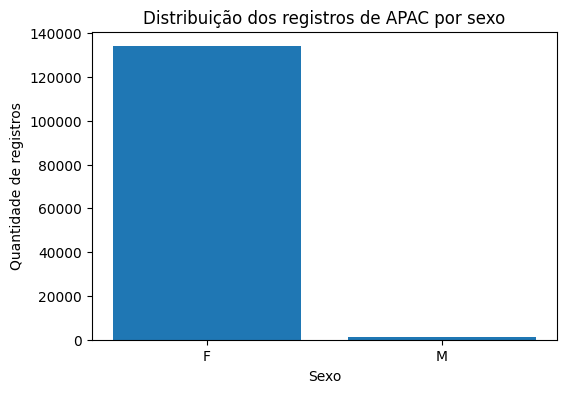

In [45]:
import matplotlib.pyplot as plt

dados_sexo = pergunta1.toPandas()

plt.figure(figsize=(6, 4))
plt.bar(dados_sexo["sexo"], dados_sexo["quantidade"])

plt.title("Distribuição dos registros de APAC por sexo")
plt.xlabel("Sexo")
plt.ylabel("Quantidade de registros")

plt.show()

**Interpretação:** Foram identificados 133.973 registros de APAC classificados como sexo feminino (aproximadamente 99,15%) e 1.142 como sexo masculino (aproximadamente 0,85%). Observa-se, portanto, predominância dos registros femininos entre as APAC de quimioterapia relacionadas ao câncer de mama analisadas. Apesar da menor frequência, também foram identificados registros referentes ao sexo masculino.

### Pergunta 2 — Como os registros de APAC estão distribuídos segundo a faixa etária?

In [46]:
pergunta2 = spark.sql("""
    SELECT
        CASE
            WHEN IDADE_ANOS < 40 THEN 'Até 39 anos'
            WHEN IDADE_ANOS BETWEEN 40 AND 49 THEN '40-49 anos'
            WHEN IDADE_ANOS BETWEEN 50 AND 59 THEN '50-59 anos'
            WHEN IDADE_ANOS BETWEEN 60 AND 69 THEN '60-69 anos'
            WHEN IDADE_ANOS BETWEEN 70 AND 79 THEN '70-79 anos'
            WHEN IDADE_ANOS >= 80 THEN '80 anos ou mais'
        END AS faixa_etaria,
        COUNT(*) AS quantidade
    FROM cancer_mama_ba_2025
    WHERE IDADE_ANOS IS NOT NULL
    GROUP BY faixa_etaria
    ORDER BY
        CASE faixa_etaria
            WHEN 'Até 39 anos' THEN 1
            WHEN '40-49 anos' THEN 2
            WHEN '50-59 anos' THEN 3
            WHEN '60-69 anos' THEN 4
            WHEN '70-79 anos' THEN 5
            WHEN '80 anos ou mais' THEN 6
        END
""")

pergunta2.show()

+---------------+----------+
|   faixa_etaria|quantidade|
+---------------+----------+
|    Até 39 anos|      8626|
|     40-49 anos|     30922|
|     50-59 anos|     38890|
|     60-69 anos|     32762|
|     70-79 anos|     16912|
|80 anos ou mais|      6962|
+---------------+----------+



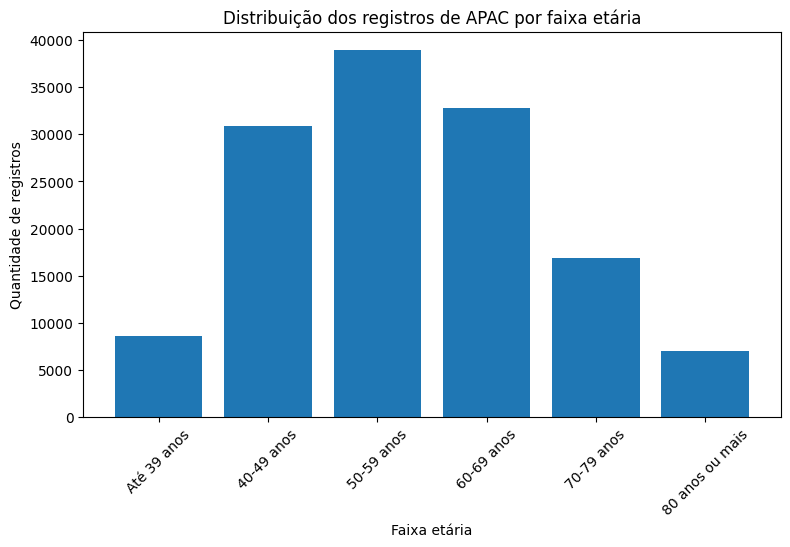

In [47]:
dados_idade = pergunta2.toPandas()

plt.figure(figsize=(9, 5))
plt.bar(
    dados_idade["faixa_etaria"],
    dados_idade["quantidade"]
)

plt.title("Distribuição dos registros de APAC por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=45)

plt.show()

**Interpretação:** A maior concentração de registros de APAC ocorreu na faixa etária de 50 a 59 anos, com 38.890 registros, seguida pelas faixas de 60 a 69 anos (32.762) e de 40 a 49 anos (30.922).

Os resultados demonstram maior concentração dos registros analisados entre 40 e 69 anos. As faixas etárias mais jovens e mais avançadas apresentaram menor frequência de registros.

Nesta análise foram considerados apenas os registros com idade válida em anos, totalizando 135.074 observações. Os 41 registros cuja idade não pôde ser interpretada com segurança foram mantidos na base original, mas não incluídos nesta análise específica.

### Pergunta 3 — Como os registros de APAC estão distribuídos segundo o estadiamento do câncer?

In [48]:
pergunta3 = spark.sql("""
    SELECT
        AQ_ESTADI AS estadio,
        COUNT(*) AS quantidade
    FROM cancer_mama_ba_2025
    GROUP BY AQ_ESTADI
    ORDER BY AQ_ESTADI
""")

pergunta3.show()

+-------+----------+
|estadio|quantidade|
+-------+----------+
|      0|      2167|
|      1|     25601|
|      2|     47332|
|      3|     45204|
|      4|     14811|
+-------+----------+



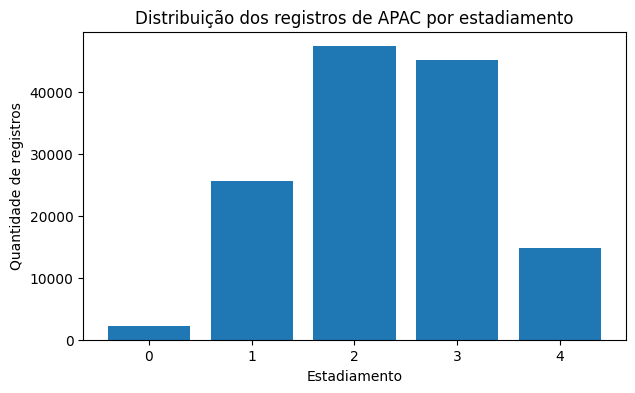

In [49]:
dados_estadio = pergunta3.toPandas()

plt.figure(figsize=(7, 4))

plt.bar(
    dados_estadio["estadio"],
    dados_estadio["quantidade"]
)

plt.title("Distribuição dos registros de APAC por estadiamento")
plt.xlabel("Estadiamento")
plt.ylabel("Quantidade de registros")

plt.show()

**Interpretação:** A análise demonstrou maior concentração dos registros de APAC nos estádios 2 e 3, com 47.332 e 45.204 registros, respectivamente. Em seguida, foram observados 25.601 registros no estádio 1, 14.811 no estádio 4 e 2.167 no estádio 0.

Os resultados descrevem a distribuição do estadiamento entre os registros de APAC de quimioterapia relacionados ao câncer de mama analisados na Bahia em 2025. Esses valores não representam diretamente a distribuição de todos os casos de câncer de mama diagnosticados no estado, uma vez que a base utilizada corresponde a registros administrativos de tratamento quimioterápico no SUS.

### Pergunta 4 — Como os registros de APAC estão distribuídos segundo raça/cor?

In [50]:
pergunta4 = spark.sql("""
    SELECT
        AP_RACACOR AS raca_cor,
        COUNT(*) AS quantidade,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentual
    FROM cancer_mama_ba_2025
    GROUP BY AP_RACACOR
    ORDER BY quantidade DESC
""")

pergunta4.show()

+--------+----------+----------+
|raca_cor|quantidade|percentual|
+--------+----------+----------+
|      03|    104113|     77.06|
|      02|     18609|     13.77|
|      01|     10493|      7.77|
|      04|      1892|      1.40|
|      05|         8|      0.01|
+--------+----------+----------+



In [52]:
pergunta4 = spark.sql("""
    SELECT
        CASE AP_RACACOR
            WHEN '01' THEN 'Branca'
            WHEN '02' THEN 'Preta'
            WHEN '03' THEN 'Parda'
            WHEN '04' THEN 'Amarela'
            WHEN '05' THEN 'Indígena'
            ELSE 'Não informado'
        END AS raca_cor,
        COUNT(*) AS quantidade,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentual
    FROM cancer_mama_ba_2025
    GROUP BY AP_RACACOR
    ORDER BY quantidade DESC
""")

pergunta4.show()

+--------+----------+----------+
|raca_cor|quantidade|percentual|
+--------+----------+----------+
|   Parda|    104113|     77.06|
|   Preta|     18609|     13.77|
|  Branca|     10493|      7.77|
| Amarela|      1892|      1.40|
|Indígena|         8|      0.01|
+--------+----------+----------+



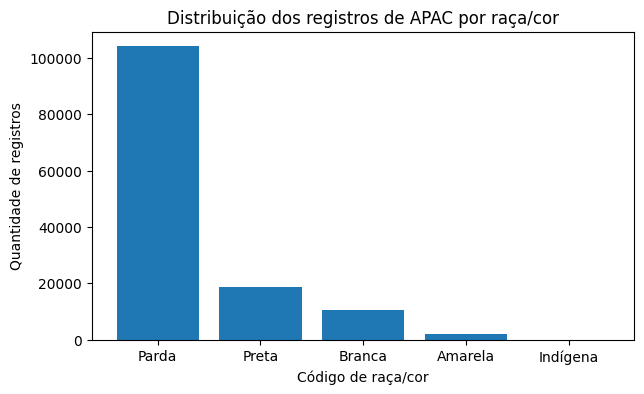

In [53]:
dados_raca = pergunta4.toPandas()

plt.figure(figsize=(7, 4))

plt.bar(
    dados_raca["raca_cor"],
    dados_raca["quantidade"]
)

plt.title("Distribuição dos registros de APAC por raça/cor")
plt.xlabel("Código de raça/cor")
plt.ylabel("Quantidade de registros")

plt.show()

**Interpretação:** A categoria de raça/cor codificada como `03` apresentou a maior frequência, com 104.113 registros (77,06%), seguida pela categoria `02`, com 18.609 registros (13,77%), e pela categoria `01`, com 10.493 registros (7,77%). As categorias `04` e `05` apresentaram menor participação, com 1.892 (1,40%) e 8 registros (0,01%), respectivamente.

A interpretação nominal das categorias será realizada de acordo com a codificação documentada para a variável `AP_RACACOR`, preservando-se nesta etapa exploratória os códigos originais da base.

### Pergunta 5 — Como a continuidade do tratamento se distribui segundo o estadiamento?

In [54]:
pergunta5 = spark.sql("""
    SELECT
        AQ_ESTADI AS estadio,
        AQ_CONTTR AS continuidade,
        COUNT(*) AS quantidade
    FROM cancer_mama_ba_2025
    GROUP BY AQ_ESTADI, AQ_CONTTR
    ORDER BY AQ_ESTADI, AQ_CONTTR
""")

pergunta5.show()

+-------+------------+----------+
|estadio|continuidade|quantidade|
+-------+------------+----------+
|      0|           N|       246|
|      0|           S|      1921|
|      1|           N|      6892|
|      1|           S|     18709|
|      2|           N|     14283|
|      2|           S|     33049|
|      3|           N|     13650|
|      3|           S|     31554|
|      4|           N|      4865|
|      4|           S|      9946|
+-------+------------+----------+



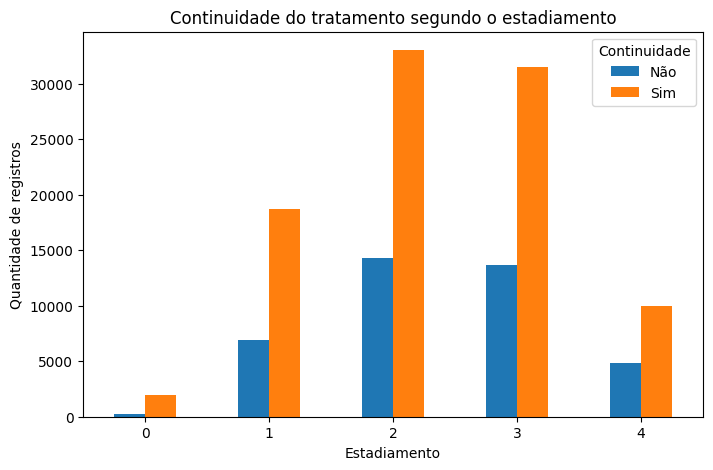

In [55]:
dados_continuidade = pergunta5.toPandas()

dados_grafico = dados_continuidade.pivot(
    index="estadio",
    columns="continuidade",
    values="quantidade"
)

dados_grafico.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Continuidade do tratamento segundo o estadiamento")
plt.xlabel("Estadiamento")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=0)
plt.legend(title="Continuidade", labels=["Não", "Sim"])

plt.show()

**Interpretação:** Em todos os estadiamentos analisados, os registros classificados como continuidade do tratamento (`S`) apresentaram maior frequência do que aqueles classificados como não continuidade (`N`).

Os estádios 2 e 3 concentraram as maiores quantidades de registros em continuidade de tratamento, com 33.049 e 31.554 registros, respectivamente. Entretanto, esses resultados devem ser interpretados considerando que os estádios 2 e 3 também apresentam maior número total de registros na base.

Assim, a comparação apresentada descreve a distribuição dos registros administrativos de APAC segundo estadiamento e continuidade do tratamento, não correspondendo diretamente ao número de pacientes em acompanhamento.

In [56]:
df_analise.select(
    "IDADE_ANOS",
    "AP_SEXO",
    "AP_RACACOR",
    "AQ_ESTADI",
    "AQ_TRANTE",
    "VALOR_APAC",
    "AQ_CONTTR"
).show(20, truncate=False)

+----------+-------+----------+---------+---------+----------+---------+
|IDADE_ANOS|AP_SEXO|AP_RACACOR|AQ_ESTADI|AQ_TRANTE|VALOR_APAC|AQ_CONTTR|
+----------+-------+----------+---------+---------+----------+---------+
|30        |F      |03        |2        |0        |1400.0    |N        |
|42        |F      |02        |3        |N        |1400.0    |S        |
|56        |F      |03        |2        |0        |2271.0    |N        |
|37        |F      |03        |3        |0        |1400.0    |N        |
|52        |F      |03        |3        |0        |1400.0    |N        |
|63        |F      |02        |3        |0        |1400.0    |S        |
|55        |F      |03        |3        |0        |1400.0    |N        |
|61        |F      |03        |2        |N        |1400.0    |N        |
|32        |F      |03        |3        |N        |2271.0    |N        |
|70        |F      |02        |3        |N        |2271.0    |N        |
|66        |F      |03        |3        |0        |

In [57]:
df_ml = df_analise.select(
    "IDADE_ANOS",
    "AP_SEXO",
    "AP_RACACOR",
    "AQ_ESTADI",
    "AQ_TRANTE",
    "AQ_CONTTR"
)

print("Registros antes da preparação:", df_ml.count())

df_ml.show(10, truncate=False)

Registros antes da preparação: 135115
+----------+-------+----------+---------+---------+---------+
|IDADE_ANOS|AP_SEXO|AP_RACACOR|AQ_ESTADI|AQ_TRANTE|AQ_CONTTR|
+----------+-------+----------+---------+---------+---------+
|30        |F      |03        |2        |0        |N        |
|42        |F      |02        |3        |N        |S        |
|56        |F      |03        |2        |0        |N        |
|37        |F      |03        |3        |0        |N        |
|52        |F      |03        |3        |0        |N        |
|63        |F      |02        |3        |0        |S        |
|55        |F      |03        |3        |0        |N        |
|61        |F      |03        |2        |N        |N        |
|32        |F      |03        |3        |N        |N        |
|70        |F      |02        |3        |N        |N        |
+----------+-------+----------+---------+---------+---------+
only showing top 10 rows


In [58]:
from pyspark.sql.functions import when, col

df_ml = df_ml.filter(
    col("IDADE_ANOS").isNotNull()
)

df_ml = df_ml.withColumn(
    "TRATAMENTO_ANTERIOR",
    when(col("AQ_TRANTE") == "S", "Sim")
    .when(col("AQ_TRANTE") == "N", "Nao")
    .otherwise("Nao_informado")
)

df_ml.groupBy("TRATAMENTO_ANTERIOR").count().show()

print("Registros disponíveis para o Machine Learning:", df_ml.count())

+-------------------+-----+
|TRATAMENTO_ANTERIOR|count|
+-------------------+-----+
|      Nao_informado|67968|
|                Sim|49021|
|                Nao|18085|
+-------------------+-----+

Registros disponíveis para o Machine Learning: 135074


In [59]:
df_ml = df_ml.withColumn(
    "label",
    when(col("AQ_CONTTR") == "S", 1.0)
    .when(col("AQ_CONTTR") == "N", 0.0)
)

df_ml.groupBy(
    "AQ_CONTTR",
    "label"
).count().show()

+---------+-----+-----+
|AQ_CONTTR|label|count|
+---------+-----+-----+
|        N|  0.0|39931|
|        S|  1.0|95143|
+---------+-----+-----+



In [63]:
from pyspark.ml.feature import StringIndexer

indexador_sexo = StringIndexer(
    inputCol="AP_SEXO",
    outputCol="SEXO_INDEX"
)

indexador_raca = StringIndexer(
    inputCol="AP_RACACOR",
    outputCol="RACA_INDEX"
)

indexador_estadio = StringIndexer(
    inputCol="AQ_ESTADI",
    outputCol="ESTADIO_INDEX"
)

indexador_tratamento = StringIndexer(
    inputCol="TRATAMENTO_ANTERIOR",
    outputCol="TRATAMENTO_INDEX"
)

In [65]:
from pyspark.ml.feature import OneHotEncoder

encoder = OneHotEncoder(
    inputCols=[
        "SEXO_INDEX",
        "RACA_INDEX",
        "ESTADIO_INDEX",
        "TRATAMENTO_INDEX"
    ],
    outputCols=[
        "SEXO_VEC",
        "RACA_VEC",
        "ESTADIO_VEC",
        "TRATAMENTO_VEC"
    ]
)

In [67]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "IDADE_ANOS",
        "SEXO_VEC",
        "RACA_VEC",
        "ESTADIO_VEC",
        "TRATAMENTO_VEC"
    ],
    outputCol="features"
)

In [68]:
treino, teste = df_ml.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Registros de treino:", treino.count())
print("Registros de teste:", teste.count())
print("Total:", treino.count() + teste.count())

Registros de treino: 107973
Registros de teste: 27101
Total: 135074


In [1]:
print(df_ml.count())

NameError: name 'df_ml' is not defined

In [2]:
!pip install pysus -q
!pip install pyspark -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.4/351.4 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0

In [3]:
import pysus
import pyspark

print("PySUS funcionando!")
print("PySpark funcionando!")

PySUS 2.11.2 -- welcome!
Data cache: /root/pysus
Change it with: pysus.set_cache('/your/path')
Browse datasets with: pysus.info()

PySUS funcionando!
PySpark funcionando!


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when

spark = SparkSession.builder \
    .appName("CancerMamaDATASUS") \
    .getOrCreate()

print("Spark iniciado!")

Spark iniciado!


In [5]:
import glob

caminhos_ba_2025 = sorted(
    glob.glob("/root/pysus/downloads/ducklake/sia/AQBA25*.parquet")
)

print("Arquivos encontrados:", len(caminhos_ba_2025))

Arquivos encontrados: 0


In [6]:
arquivos_ba_2025 = []

for mes in range(1, 13):
    try:
        arquivo = pysus.ftp.sia(
            state="BA",
            year=2025,
            month=mes,
            group="AQ"
        )

        arquivos_ba_2025.append(arquivo)

        print("✓ BA", mes, "- download concluído")

    except Exception as erro:
        print("✗ BA", mes, "- erro:", erro)

print("\nMeses processados:", len(arquivos_ba_2025))

AQBA2501.parquet: 0.00B [00:00, ?B/s]
AQBA2501.parquet:   0%|          | 0.00/1.30M [00:00<?, ?B/s]
AQBA2501.parquet:   5%|▌         | 65.5k/1.30M [00:00<00:00, 11.2MB/s]
AQBA2501.parquet:  10%|█         | 131k/1.30M [00:00<00:01, 1.02MB/s] 
AQBA2501.parquet:  15%|█▌        | 197k/1.30M [00:00<00:01, 977kB/s] 
AQBA2501.parquet:  20%|██        | 262k/1.30M [00:00<00:01, 1.01MB/s]
AQBA2501.parquet:  25%|██▌       | 328k/1.30M [00:00<00:00, 1.04MB/s]
AQBA2501.parquet:  30%|███       | 393k/1.30M [00:00<00:00, 1.12MB/s]
AQBA2501.parquet:  35%|███▌      | 459k/1.30M [00:00<00:00, 1.20MB/s]
AQBA2501.parquet:  40%|████      | 524k/1.30M [00:00<00:00, 1.29MB/s]
AQBA2501.parquet:  45%|████▌     | 590k/1.30M [00:00<00:00, 1.36MB/s]
AQBA2501.parquet:  50%|█████     | 655k/1.30M [00:00<00:00, 1.44MB/s]
AQBA2501.parquet:  55%|█████▌    | 721k/1.30M [00:00<00:00, 1.52MB/s]
AQBA2501.parquet:  60%|██████    | 786k/1.30M [00:00<00:00, 1.60MB/s]
AQBA2501.parquet:  66%|██████▌   | 852k/1.30M [00:00<00:00

✓ BA 1 - download concluído


AQBA2502.parquet: 0.00B [00:00, ?B/s]
AQBA2502.parquet:   0%|          | 0.00/1.35M [00:00<?, ?B/s]
AQBA2502.parquet:   5%|▍         | 65.5k/1.35M [00:00<00:00, 16.3MB/s]
AQBA2502.parquet:  10%|▉         | 131k/1.35M [00:00<00:01, 787kB/s]  
AQBA2502.parquet:  15%|█▍        | 197k/1.35M [00:00<00:01, 837kB/s]
AQBA2502.parquet:  19%|█▉        | 262k/1.35M [00:00<00:01, 895kB/s]
AQBA2502.parquet:  24%|██▍       | 328k/1.35M [00:00<00:01, 967kB/s]
AQBA2502.parquet:  29%|██▉       | 393k/1.35M [00:00<00:00, 1.02MB/s]
AQBA2502.parquet:  34%|███▍      | 459k/1.35M [00:00<00:00, 1.11MB/s]
AQBA2502.parquet:  39%|███▉      | 524k/1.35M [00:00<00:00, 1.20MB/s]
AQBA2502.parquet:  44%|████▍     | 590k/1.35M [00:00<00:00, 1.26MB/s]
AQBA2502.parquet:  49%|████▊     | 655k/1.35M [00:00<00:00, 1.34MB/s]
AQBA2502.parquet:  54%|█████▎    | 721k/1.35M [00:00<00:00, 1.42MB/s]
AQBA2502.parquet:  58%|█████▊    | 786k/1.35M [00:00<00:00, 1.50MB/s]
AQBA2502.parquet:  63%|██████▎   | 852k/1.35M [00:00<00:00, 1

✓ BA 2 - download concluído


AQBA2503.parquet: 0.00B [00:00, ?B/s]
AQBA2503.parquet:   0%|          | 0.00/1.31M [00:00<?, ?B/s]
AQBA2503.parquet:   5%|▍         | 65.5k/1.31M [00:00<00:00, 22.8MB/s]
AQBA2503.parquet:  10%|▉         | 131k/1.31M [00:00<00:01, 976kB/s]  
AQBA2503.parquet:  15%|█▍        | 197k/1.31M [00:00<00:01, 943kB/s]
AQBA2503.parquet:  20%|█▉        | 262k/1.31M [00:00<00:01, 983kB/s]
AQBA2503.parquet:  25%|██▍       | 328k/1.31M [00:00<00:00, 1.02MB/s]
AQBA2503.parquet:  30%|██▉       | 393k/1.31M [00:00<00:00, 1.10MB/s]
AQBA2503.parquet:  35%|███▍      | 459k/1.31M [00:00<00:00, 1.19MB/s]
AQBA2503.parquet:  40%|███▉      | 524k/1.31M [00:00<00:00, 1.25MB/s]
AQBA2503.parquet:  45%|████▍     | 590k/1.31M [00:00<00:00, 1.34MB/s]
AQBA2503.parquet:  50%|████▉     | 655k/1.31M [00:00<00:00, 1.42MB/s]
AQBA2503.parquet:  55%|█████▍    | 721k/1.31M [00:00<00:00, 1.50MB/s]
AQBA2503.parquet:  60%|█████▉    | 786k/1.31M [00:00<00:00, 1.56MB/s]
AQBA2503.parquet:  65%|██████▍   | 852k/1.31M [00:00<00:00, 

...

✓ BA 10 - download concluído


AQBA2511.parquet: 0.00B [00:00, ?B/s]
AQBA2511.parquet:   0%|          | 0.00/1.50M [00:00<?, ?B/s]
AQBA2511.parquet:   4%|▍         | 65.5k/1.50M [00:00<00:00, 10.5MB/s]
AQBA2511.parquet:   9%|▊         | 131k/1.50M [00:00<00:01, 958kB/s]  
AQBA2511.parquet:  13%|█▎        | 197k/1.50M [00:00<00:01, 924kB/s]
AQBA2511.parquet:  17%|█▋        | 262k/1.50M [00:00<00:01, 964kB/s]
AQBA2511.parquet:  22%|██▏       | 328k/1.50M [00:00<00:01, 996kB/s]
AQBA2511.parquet:  26%|██▌       | 393k/1.50M [00:00<00:01, 1.08MB/s]
AQBA2511.parquet:  31%|███       | 459k/1.50M [00:00<00:00, 1.16MB/s]
AQBA2511.parquet:  35%|███▍      | 524k/1.50M [00:00<00:00, 1.22MB/s]
AQBA2511.parquet:  39%|███▉      | 590k/1.50M [00:00<00:00, 1.30MB/s]
AQBA2511.parquet:  44%|████▎     | 655k/1.50M [00:00<00:00, 1.39MB/s]
AQBA2511.parquet:  48%|████▊     | 721k/1.50M [00:00<00:00, 1.46MB/s]
AQBA2511.parquet:  52%|█████▏    | 786k/1.50M [00:00<00:00, 1.53MB/s]
AQBA2511.parquet:  57%|█████▋    | 852k/1.50M [00:00<00:00, 1

✓ BA 11 - download concluído


AQBA2512.parquet: 0.00B [00:00, ?B/s]
AQBA2512.parquet:   0%|          | 0.00/1.28M [00:00<?, ?B/s]
AQBA2512.parquet:   5%|▌         | 65.5k/1.28M [00:00<00:00, 14.8MB/s]
AQBA2512.parquet:  10%|█         | 131k/1.28M [00:00<00:01, 973kB/s]  
AQBA2512.parquet:  15%|█▌        | 197k/1.28M [00:00<00:01, 957kB/s]
AQBA2512.parquet:  21%|██        | 262k/1.28M [00:00<00:01, 990kB/s]
AQBA2512.parquet:  26%|██▌       | 328k/1.28M [00:00<00:00, 1.01MB/s]
AQBA2512.parquet:  31%|███       | 393k/1.28M [00:00<00:00, 1.10MB/s]
AQBA2512.parquet:  36%|███▌      | 459k/1.28M [00:00<00:00, 1.18MB/s]
AQBA2512.parquet:  41%|████      | 524k/1.28M [00:00<00:00, 1.25MB/s]
AQBA2512.parquet:  46%|████▌     | 590k/1.28M [00:00<00:00, 1.33MB/s]
AQBA2512.parquet:  51%|█████▏    | 655k/1.28M [00:00<00:00, 1.42MB/s]
AQBA2512.parquet:  56%|█████▋    | 721k/1.28M [00:00<00:00, 1.50MB/s]
AQBA2512.parquet:  62%|██████▏   | 786k/1.28M [00:00<00:00, 1.56MB/s]
AQBA2512.parquet:  67%|██████▋   | 852k/1.28M [00:00<00:00, 

✓ BA 12 - download concluído

Meses processados: 12


In [7]:
import glob

caminhos_ba_2025 = sorted(
    glob.glob("/root/pysus/downloads/ducklake/sia/AQBA25*.parquet")
)

print("Arquivos encontrados:", len(caminhos_ba_2025))

df_ba_2025 = spark.read.parquet(*caminhos_ba_2025)

print("Registros Bahia 2025:", df_ba_2025.count())
print("Número de variáveis:", len(df_ba_2025.columns))

Arquivos encontrados: 12
Registros Bahia 2025: 283432
Número de variáveis: 74


In [8]:
from pyspark.sql.functions import col, when

# 1. Filtrar somente registros relacionados ao câncer de mama (CID C50)
df_mama_ba_2025 = df_ba_2025.filter(
    col("AP_CIDPRI").startswith("C50")
)

# 2. Criar idade válida em anos
df_mama_ba_2025 = df_mama_ba_2025.withColumn(
    "IDADE_ANOS",
    when(
        col("AP_COIDADE") == "4",
        col("AP_NUIDADE").cast("integer")
    )
)

# 3. Transformar valor da APAC em número decimal
df_mama_ba_2025 = df_mama_ba_2025.withColumn(
    "VALOR_APAC",
    col("AP_VL_AP").cast("double")
)

# 4. Criar novamente nossa base de análise
df_analise = df_mama_ba_2025.select(
    "AP_CMP",
    "AP_SEXO",
    "AP_RACACOR",
    "AP_MUNPCN",
    "AP_CIDPRI",
    "AP_PRIPAL",
    "AQ_ESTADI",
    "AQ_GRAHIS",
    "AQ_TRANTE",
    "AQ_CONTTR",
    "IDADE_ANOS",
    "VALOR_APAC"
)

print("Registros C50:", df_mama_ba_2025.count())
print("Registros df_analise:", df_analise.count())

Registros C50: 135115
Registros df_analise: 135115


In [9]:
from pyspark.sql.functions import col, when

df_ml = df_analise.select(
    "IDADE_ANOS",
    "AP_SEXO",
    "AP_RACACOR",
    "AQ_ESTADI",
    "AQ_TRANTE",
    "AQ_CONTTR"
)

# Manter para o ML apenas registros com idade válida
df_ml = df_ml.filter(
    col("IDADE_ANOS").isNotNull()
)

# Organizar tratamento anterior
df_ml = df_ml.withColumn(
    "TRATAMENTO_ANTERIOR",
    when(col("AQ_TRANTE") == "S", "Sim")
    .when(col("AQ_TRANTE") == "N", "Nao")
    .otherwise("Nao_informado")
)

# Criar variável-alvo:
# Sim = 1 / Não = 0
df_ml = df_ml.withColumn(
    "label",
    when(col("AQ_CONTTR") == "S", 1.0)
    .when(col("AQ_CONTTR") == "N", 0.0)
)

print("Registros disponíveis para ML:", df_ml.count())

df_ml.groupBy("AQ_CONTTR", "label").count().show()

Registros disponíveis para ML: 135074
+---------+-----+-----+
|AQ_CONTTR|label|count|
+---------+-----+-----+
|        N|  0.0|39931|
|        S|  1.0|95143|
+---------+-----+-----+



## 4. Modelagem Preditiva

Nesta etapa foi realizada a modelagem preditiva utilizando algoritmos de classificação, com o objetivo de identificar padrões associados à variável de continuidade do tratamento (`AQ_CONTTR`) registrada nas APAC de quimioterapia.

A variável `AQ_CONTTR` foi definida como variável-alvo e transformada em uma classificação binária:

- **1 = Sim:** registro classificado como continuidade do tratamento;
- **0 = Não:** registro classificado como não continuidade do tratamento.

Como variáveis preditoras foram utilizadas **idade, sexo, raça/cor, estadiamento e informação sobre tratamento anterior**.

Ressalta-se que `AQ_CONTTR` corresponde a uma informação administrativa registrada na APAC. Dessa forma, a categoria “Não” não será interpretada como abandono do tratamento ou interrupção clínica do acompanhamento do paciente.

Para o desenvolvimento dos modelos, foram considerados **135.074 registros com idade válida**. A base foi dividida aleatoriamente em **80% para treinamento e 20% para teste**, utilizando `seed=42` para favorecer a reprodutibilidade. A divisão resultou em **107.973 registros para treinamento e 27.101 registros para teste**.

Foram selecionados dois algoritmos de classificação de famílias distintas: **Regressão Logística** e **Random Forest**. A Random Forest também atende ao requisito de utilização de um método *ensemble*. O desempenho dos modelos será comparado por meio de métricas de classificação.

In [10]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

# Transformar categorias de texto em índices numéricos
indexador_sexo = StringIndexer(
    inputCol="AP_SEXO",
    outputCol="SEXO_INDEX",
    handleInvalid="keep"
)

indexador_raca = StringIndexer(
    inputCol="AP_RACACOR",
    outputCol="RACA_INDEX",
    handleInvalid="keep"
)

indexador_estadio = StringIndexer(
    inputCol="AQ_ESTADI",
    outputCol="ESTADIO_INDEX",
    handleInvalid="keep"
)

indexador_tratamento = StringIndexer(
    inputCol="TRATAMENTO_ANTERIOR",
    outputCol="TRATAMENTO_INDEX",
    handleInvalid="keep"
)

# Transformar os índices em representações adequadas para o modelo
encoder = OneHotEncoder(
    inputCols=[
        "SEXO_INDEX",
        "RACA_INDEX",
        "ESTADIO_INDEX",
        "TRATAMENTO_INDEX"
    ],
    outputCols=[
        "SEXO_VEC",
        "RACA_VEC",
        "ESTADIO_VEC",
        "TRATAMENTO_VEC"
    ]
)

# Juntar todas as variáveis que serão usadas para fazer a previsão
assembler = VectorAssembler(
    inputCols=[
        "IDADE_ANOS",
        "SEXO_VEC",
        "RACA_VEC",
        "ESTADIO_VEC",
        "TRATAMENTO_VEC"
    ],
    outputCol="features"
)

print("Preparação do Machine Learning reconstruída!")

Preparação do Machine Learning reconstruída!


In [11]:
treino, teste = df_ml.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Registros para TREINO:", treino.count())
print("Registros para TESTE:", teste.count())
print("Total:", treino.count() + teste.count())

Registros para TREINO: 107973
Registros para TESTE: 27101
Total: 135074


### 4.1 Regressão Logística

A Regressão Logística foi utilizada como primeiro algoritmo de classificação. O modelo foi treinado utilizando exclusivamente o conjunto de treinamento e posteriormente aplicado ao conjunto de teste, permitindo comparar as classificações previstas pelo modelo com os valores reais da variável-alvo.

As variáveis categóricas foram previamente transformadas em representações numéricas por meio de `StringIndexer` e `OneHotEncoder`. Em seguida, as variáveis preditoras foram reunidas em um único vetor de características (`features`) utilizando `VectorAssembler`.

Essas etapas foram organizadas em um `Pipeline` do PySpark, garantindo que o processamento das variáveis e o treinamento do modelo fossem realizados de maneira sequencial e padronizada.

In [12]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

# Modelo de Regressão Logística
regressao_logistica = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100
)

# Pipeline: organiza todas as etapas até chegar ao modelo
pipeline_lr = Pipeline(
    stages=[
        indexador_sexo,
        indexador_raca,
        indexador_estadio,
        indexador_tratamento,
        encoder,
        assembler,
        regressao_logistica
    ]
)

print("Pipeline da Regressão Logística criado!")

Pipeline da Regressão Logística criado!


In [13]:
modelo_lr = pipeline_lr.fit(treino)

print("Regressão Logística treinada com sucesso!")

Regressão Logística treinada com sucesso!


In [14]:
previsoes_lr = modelo_lr.transform(teste)

previsoes_lr.select(
    "label",
    "prediction"
).show(10)

+-----+----------+
|label|prediction|
+-----+----------+
|  1.0|       1.0|
|  1.0|       0.0|
|  1.0|       0.0|
|  1.0|       1.0|
|  0.0|       1.0|
|  0.0|       0.0|
|  1.0|       1.0|
|  1.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
+-----+----------+
only showing top 10 rows


In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Acurácia
avaliador_acuracia = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

acuracia_lr = avaliador_acuracia.evaluate(previsoes_lr)

# F1
avaliador_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

f1_lr = avaliador_f1.evaluate(previsoes_lr)

# AUC
avaliador_auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

auc_lr = avaliador_auc.evaluate(previsoes_lr)

print("REGRESSÃO LOGÍSTICA")
print("Acurácia:", round(acuracia_lr, 4))
print("F1:", round(f1_lr, 4))
print("AUC:", round(auc_lr, 4))

In [15]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# Acurácia
acuracia_lr = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(previsoes_lr)

# F1
f1_lr = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(previsoes_lr)

# AUC
auc_lr = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
).evaluate(previsoes_lr)

print("REGRESSÃO LOGÍSTICA")
print("Acurácia:", round(acuracia_lr, 4))
print("F1:", round(f1_lr, 4))
print("AUC:", round(auc_lr, 4))

REGRESSÃO LOGÍSTICA
Acurácia: 0.7048
F1: 0.6085
AUC: 0.7066


#### Avaliação da Regressão Logística

A Regressão Logística apresentou **acurácia de 70,48%**, **F1 de 0,6085** e **AUC de 0,7066** no conjunto de teste.

A acurácia deve ser interpretada com cautela, pois aproximadamente 70% dos registros da base pertencem à categoria de continuidade do tratamento (`S`). Dessa forma, a proporção geral de acertos, isoladamente, não é suficiente para determinar a qualidade do modelo.

O valor de AUC de 0,7066 indica que o modelo apresentou capacidade de discriminação entre as duas classes superior a uma classificação aleatória. Entretanto, o desempenho deverá ser analisado em conjunto com as demais métricas e comparado ao segundo algoritmo utilizado no estudo.

Na etapa seguinte, será aplicado o algoritmo Random Forest, permitindo comparar o desempenho dos dois métodos de classificação.

### 4.2 Random Forest

O segundo algoritmo utilizado foi o Random Forest, um método de classificação do tipo *ensemble*. Esse algoritmo combina diversas árvores de decisão para produzir a classificação final.

Neste estudo foram utilizadas 50 árvores de decisão (`numTrees=50`). O modelo foi treinado utilizando o mesmo conjunto de treinamento empregado na Regressão Logística e avaliado sobre o mesmo conjunto de teste, permitindo a comparação dos resultados entre os dois algoritmos.

In [16]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline

random_forest = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=50,
    seed=42
)

pipeline_rf = Pipeline(
    stages=[
        indexador_sexo,
        indexador_raca,
        indexador_estadio,
        indexador_tratamento,
        encoder,
        assembler,
        random_forest
    ]
)

modelo_rf = pipeline_rf.fit(treino)

print("Random Forest treinada com sucesso!")

Random Forest treinada com sucesso!


In [17]:
# Fazer previsões no conjunto de teste
previsoes_rf = modelo_rf.transform(teste)

# Acurácia
acuracia_rf = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(previsoes_rf)

# F1
f1_rf = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(previsoes_rf)

# AUC
auc_rf = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
).evaluate(previsoes_rf)

print("RANDOM FOREST")
print("Acurácia:", round(acuracia_rf, 4))
print("F1:", round(f1_rf, 4))
print("AUC:", round(auc_rf, 4))

RANDOM FOREST
Acurácia: 0.7076
F1: 0.5864
AUC: 0.7184


#### Avaliação da Random Forest

A Random Forest apresentou **acurácia de 70,76%**, **F1 de 0,5864** e **AUC de 0,7184** no conjunto de teste.

Assim como observado na Regressão Logística, a acurácia deve ser interpretada com cautela devido à maior frequência da classe de continuidade do tratamento (`S`) na base analisada.

A Random Forest apresentou AUC de 0,7184, indicando capacidade de discriminação entre as classes superior a uma classificação aleatória. Os resultados foram comparados com os obtidos pela Regressão Logística para avaliar as diferenças de desempenho entre os algoritmos.

In [18]:
comparacao_modelos = spark.createDataFrame([
    ("Regressão Logística", acuracia_lr, f1_lr, auc_lr),
    ("Random Forest", acuracia_rf, f1_rf, auc_rf)
], ["Modelo", "Acurácia", "F1", "AUC"])

comparacao_modelos.show(truncate=False)

+-------------------+------------------+------------------+------------------+
|Modelo             |Acurácia          |F1                |AUC               |
+-------------------+------------------+------------------+------------------+
|Regressão Logística|0.7047710416589794|0.6084675930299682|0.7065664395162717|
|Random Forest      |0.7075753662226486|0.5864021100194702|0.7184184982805796|
+-------------------+------------------+------------------+------------------+



#### 4.3 Comparação dos modelos preditivos

Os dois algoritmos apresentaram resultados semelhantes no conjunto de teste.

A **Regressão Logística** apresentou acurácia de **70,48%**, F1 de **0,6085** e AUC de **0,7066**. A **Random Forest** apresentou acurácia de **70,76%**, F1 de **0,5864** e AUC de **0,7184**.

A Random Forest apresentou valores ligeiramente superiores de acurácia e AUC, enquanto a Regressão Logística apresentou maior valor de F1. Dessa forma, as métricas não apontam superioridade uniforme de um único algoritmo em todos os critérios avaliados.

Além disso, como aproximadamente 70% dos registros pertencem à classe de continuidade do tratamento (`S`), a acurácia isoladamente deve ser interpretada com cautela. Os resultados indicam que as variáveis utilizadas apresentam alguma capacidade de discriminar as categorias de continuidade registradas na APAC, porém com desempenho moderado.

Ressalta-se que os modelos classificam registros administrativos de APAC e não devem ser interpretados como modelos de previsão de abandono do tratamento ou de evolução clínica individual dos pacientes.

## 5. Modelagem Descritiva — K-Means

Após a modelagem preditiva, foi realizada uma análise de agrupamento utilizando o algoritmo **K-Means**, com o objetivo de identificar grupos de registros com características semelhantes dentro da base analisada.

Diferentemente dos modelos de classificação utilizados anteriormente, o K-Means é um algoritmo de aprendizado não supervisionado. Isso significa que não existe uma variável-alvo que o modelo tente prever. O algoritmo identifica padrões de similaridade entre os registros e os organiza em grupos denominados *clusters*.

Para esta análise foram utilizadas características demográficas e clínicas disponíveis nos registros. O número de clusters será avaliado por meio da métrica **Silhouette**, permitindo comparar diferentes possibilidades de agrupamento.

In [19]:
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import when, col

df_cluster = df_ml.withColumn(
    "ESTADIO_NUM",
    col("AQ_ESTADI").cast("double")
).withColumn(
    "TRATAMENTO_NUM",
    when(col("TRATAMENTO_ANTERIOR") == "Sim", 1.0)
    .when(col("TRATAMENTO_ANTERIOR") == "Nao", 0.0)
    .otherwise(0.5)
)

# Manter apenas os registros necessários para o agrupamento
df_cluster = df_cluster.select(
    "IDADE_ANOS",
    "ESTADIO_NUM",
    "TRATAMENTO_NUM"
).dropna()

print("Registros disponíveis para clustering:", df_cluster.count())

df_cluster.show(5)

Registros disponíveis para clustering: 135074
+----------+-----------+--------------+
|IDADE_ANOS|ESTADIO_NUM|TRATAMENTO_NUM|
+----------+-----------+--------------+
|        30|        2.0|           0.5|
|        42|        3.0|           0.0|
|        56|        2.0|           0.5|
|        37|        3.0|           0.5|
|        52|        3.0|           0.5|
+----------+-----------+--------------+
only showing top 5 rows


In [20]:
from pyspark.ml.feature import VectorAssembler

assembler_cluster = VectorAssembler(
    inputCols=[
        "IDADE_ANOS",
        "ESTADIO_NUM",
        "TRATAMENTO_NUM"
    ],
    outputCol="features_cluster"
)

df_cluster_pronto = assembler_cluster.transform(df_cluster)

print("Dados preparados para o K-Means!")

Dados preparados para o K-Means!


In [21]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

avaliador_cluster = ClusteringEvaluator(
    featuresCol="features_cluster",
    predictionCol="prediction",
    metricName="silhouette"
)

resultados_k = []

for k in [2, 3, 4]:

    kmeans = KMeans(
        featuresCol="features_cluster",
        predictionCol="prediction",
        k=k,
        seed=42
    )

    modelo_k = kmeans.fit(df_cluster_pronto)

    previsoes_k = modelo_k.transform(df_cluster_pronto)

    silhouette = avaliador_cluster.evaluate(previsoes_k)

    resultados_k.append((k, silhouette))

    print("K =", k, "| Silhouette =", round(silhouette, 4))

K = 2 | Silhouette = 0.7346
K = 3 | Silhouette = 0.6908
K = 4 | Silhouette = 0.6594


In [22]:
kmeans_final = KMeans(
    featuresCol="features_cluster",
    predictionCol="cluster",
    k=2,
    seed=42
)

modelo_kmeans = kmeans_final.fit(df_cluster_pronto)

resultado_clusters = modelo_kmeans.transform(df_cluster_pronto)

print("K-Means finalizado com 2 clusters!")

resultado_clusters.groupBy("cluster").count().show()

K-Means finalizado com 2 clusters!
+-------+-----+
|cluster|count|
+-------+-----+
|      1|78438|
|      0|56636|
+-------+-----+



In [23]:
from pyspark.sql.functions import avg, count

perfil_clusters = resultado_clusters.groupBy("cluster").agg(
    count("*").alias("quantidade"),
    avg("IDADE_ANOS").alias("idade_media"),
    avg("ESTADIO_NUM").alias("estadio_medio"),
    avg("TRATAMENTO_NUM").alias("tratamento_anterior_medio")
)

perfil_clusters.orderBy("cluster").show()

+-------+----------+------------------+------------------+-------------------------+
|cluster|quantidade|       idade_media|     estadio_medio|tratamento_anterior_medio|
+-------+----------+------------------+------------------+-------------------------+
|      0|     56636| 69.59483367469454|  2.23864679709019|        0.620753584292676|
|      1|     78438|48.692763711466384|2.3989775363981742|       0.6100104541166271|
+-------+----------+------------------+------------------+-------------------------+



In [24]:
resultado_clusters.groupBy(
    "cluster",
    "TRATAMENTO_NUM"
).count().orderBy(
    "cluster",
    "TRATAMENTO_NUM"
).show()

+-------+--------------+-----+
|cluster|TRATAMENTO_NUM|count|
+-------+--------------+-----+
|      0|           0.0| 7532|
|      0|           0.5|27894|
|      0|           1.0|21210|
|      1|           0.0|10553|
|      1|           0.5|40074|
|      1|           1.0|27811|
+-------+--------------+-----+



### 5.1 Definição do número de clusters

Para definir o número de grupos, foram testadas soluções com 2, 3 e 4 clusters. A qualidade dos agrupamentos foi avaliada utilizando a métrica Silhouette.

Os resultados obtidos foram:

- **K = 2:** Silhouette = 0,7346
- **K = 3:** Silhouette = 0,6908
- **K = 4:** Silhouette = 0,6594

Entre as alternativas avaliadas, a solução com **2 clusters apresentou o maior valor de Silhouette (0,7346)**. Dessa forma, foi selecionado K = 2 para a modelagem final.

### 5.2 Caracterização dos clusters

O modelo K-Means com dois clusters distribuiu os 135.074 registros analisados em:

- **Cluster 0:** 56.636 registros;
- **Cluster 1:** 78.438 registros.

O **Cluster 0** apresentou idade média de aproximadamente **69,6 anos** e estadiamento médio de **2,24**. O **Cluster 1** apresentou idade média de aproximadamente **48,7 anos** e estadiamento médio de **2,40**.

A principal diferença observada entre os grupos foi a idade, com o Cluster 0 concentrando registros associados a idades mais elevadas e o Cluster 1 apresentando idade média aproximadamente 21 anos menor.

Em relação à informação sobre tratamento anterior, os dois clusters apresentaram distribuição semelhante entre as categorias “Sim”, “Não” e “Não informado”. O estadiamento médio também apresentou pequena diferença entre os grupos.

Assim, dentro das características utilizadas no agrupamento, a **idade foi a variável que mais diferenciou os perfis identificados pelo K-Means**.

Os clusters representam agrupamentos estatísticos de registros com características semelhantes e não devem ser interpretados como categorias clínicas, prognósticas ou grupos de pacientes individuais.

## 6. Interpretação dos Resultados e Conclusões — KDD

O processo de descoberta de conhecimento foi desenvolvido a partir dos registros de APAC de quimioterapia do SIA/SUS referentes ao estado da Bahia no ano de 2025. Após a integração dos 12 arquivos mensais, foram identificados 283.432 registros de quimioterapia, dos quais 135.115 apresentaram diagnóstico principal iniciado por C50, correspondente às neoplasias malignas da mama.

### 6.1 Principais conhecimentos identificados

A análise exploratória demonstrou forte predominância de registros classificados como sexo feminino, com 133.973 registros (99,15%), embora também tenham sido identificados 1.142 registros classificados como sexo masculino (0,85%).

Em relação à idade, observou-se maior concentração dos registros entre 40 e 69 anos, com destaque para a faixa de 50 a 59 anos, que apresentou 38.890 registros.

Quanto ao estadiamento, os estádios 2 e 3 apresentaram as maiores frequências, com 47.332 e 45.204 registros, respectivamente.

Na variável raça/cor, a categoria parda apresentou maior frequência, correspondendo a 77,06% dos registros analisados.

A análise da continuidade do tratamento demonstrou maior frequência da categoria “Sim” em todos os estadiamentos. Entretanto, por se tratar de uma variável administrativa da APAC, esse resultado não deve ser interpretado diretamente como medida de adesão ou abandono do tratamento.

### 6.2 Modelagem preditiva

Foram utilizados dois algoritmos de classificação: Regressão Logística e Random Forest.

A Regressão Logística apresentou acurácia de 70,48%, F1 de 0,6085 e AUC de 0,7066. A Random Forest apresentou acurácia de 70,76%, F1 de 0,5864 e AUC de 0,7184.

Os modelos apresentaram resultados próximos. A Random Forest obteve maior AUC e acurácia, enquanto a Regressão Logística apresentou maior F1. Considerando o desequilíbrio entre as classes da variável-alvo, a acurácia isoladamente não deve ser utilizada para avaliar o desempenho dos modelos.

Os resultados demonstram que as características utilizadas apresentam alguma capacidade de discriminação entre as categorias de continuidade registradas na APAC, porém o desempenho observado foi moderado.

### 6.3 Modelagem descritiva

Na análise de agrupamento com K-Means foram testadas soluções com 2, 3 e 4 clusters. A solução com dois clusters apresentou o maior valor de Silhouette (0,7346) e foi selecionada para a análise final.

O Cluster 0 apresentou 56.636 registros e idade média de aproximadamente 69,6 anos, enquanto o Cluster 1 apresentou 78.438 registros e idade média de aproximadamente 48,7 anos.

A idade foi a característica que mais diferenciou os dois grupos identificados. O estadiamento médio e a distribuição da informação sobre tratamento anterior apresentaram diferenças menores entre os clusters.

### 6.4 Limitações

Os dados analisados são registros administrativos de APAC de quimioterapia e, portanto, não representam diretamente o número de pacientes com câncer de mama na Bahia. Um mesmo indivíduo pode possuir múltiplos registros ao longo do tratamento.

A base também não representa todos os casos diagnosticados de câncer de mama no estado, mas o conjunto de registros de quimioterapia do SUS incluídos no recorte analisado.

A variável de continuidade do tratamento possui natureza administrativa e não permite concluir, isoladamente, que a categoria “Não” represente abandono ou interrupção clínica do tratamento.

Na análise de clustering, as variáveis utilizadas possuem escalas numéricas diferentes. Como não foi realizada padronização prévia das características, a idade pode ter exercido maior influência na formação dos clusters, devendo esse aspecto ser considerado na interpretação dos resultados.

### 6.5 Conclusão

A utilização de PySpark permitiu realizar a ingestão, o pré-processamento e a análise de um conjunto de dados com mais de 100 mil registros, atendendo ao requisito de processamento de dados em maior volume proposto no projeto.

A aplicação de Spark SQL possibilitou identificar padrões demográficos e clínicos presentes nos registros, enquanto os algoritmos de classificação permitiram avaliar a capacidade das variáveis selecionadas de discriminar a continuidade registrada nas APAC. A análise de clustering complementou o estudo ao identificar dois perfis estatísticos distintos, diferenciados principalmente pela idade.

Como continuidade do projeto, estudos futuros poderiam incorporar outras variáveis disponíveis no SIA/SUS, realizar padronização das características utilizadas no clustering, explorar estratégias para tratamento do desequilíbrio entre as classes e integrar outras fontes de dados do DATASUS para ampliar a compreensão dos padrões relacionados ao tratamento do câncer de mama.